# 复现回测结果

验证本地回测与 `--from-predictions` 结果一致。

In [21]:
1

1

In [22]:
import os, sys, pickle, json
import pandas as pd
import numpy as np
sys.path.insert(0, '../code/src')
from backtest import ETFBacktester, run_backtest, run_backtest_from_predictions
import warnings
warnings.filterwarnings('ignore')

## 配置

In [23]:
MODEL_FILE = "best_model_sliding.pth"
DATA_PATH = "../etf_data/etf_74.csv"
CACHE_DIR = "../output/predictions_cache_2026_01_01_to_2026_05_27"
BT_CACHE_DIR = "../output/backtest_cache_2026_01_01_to_2026_05_27"
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(BT_CACHE_DIR, exist_ok=True)

START_DATE = "2026-01-01"
END_DATE = "2026-05-27"
TOP_K = 3
REBALANCE_DAYS = 5
POSITION_PCT = 0.95
INITIAL_CAPITAL = 100000

In [24]:
import glob
from tqdm import tqdm

BASE_DIR = "../model"
# DL models (per-trial PyTorch checkpoints)
DL_TYPES = [
    "bayes_itransformer_74_3_2026-01-01_2026-03-31",
    "bayes_dlinear_74_3_2026-01-01_2026-03-31",
    "bayes_gru_74_3_2026-01-01_2026-03-31",
    "bayes_patchtst_74_3_2026-01-01_2026-03-31",
    "bayes_mamba_74_3_2026-01-01_2026-03-31",
    "bayes_nlinear_74_3_2026-01-01_2026-03-31",
    "bayes_timesnet_74_3_2026-01-01_2026-03-31",
    "bayes_tcn_74_3_2026-01-01_2026-03-31",
    "bayes_lstm_74_3_2026-01-01_2026-03-31",
]
# ML models (retrained best model as .pkl)
ML_TYPES = [
    "bayes_xgb_2026-01-01_2026-03-31",
    "bayes_lightgbm_2026-01-01_2026-03-31",
    "bayes_catboost_2026-01-01_2026-03-31",
    "grid_xgb_2026-01-01_2026-03-31",
]
# 合并方便展示循环用
MODEL_TYPES = DL_TYPES + ML_TYPES
# 数据加载需要 DL 模型的 scaler
MODEL_DIR = f"../model/{DL_TYPES[0]}/exp_0"


EXPERIMENTS = []
# DL: scan exp_* subdirs for .pth checkpoints
for mt in DL_TYPES:
    cnt = 0
    for exp_dir in sorted(glob.glob(f"{BASE_DIR}/{mt}/exp_*")):
        if os.path.exists(f"{exp_dir}/best_model_sliding.pth"):
            EXPERIMENTS.append((exp_dir, "best_model_sliding.pth"))
        if os.path.exists(f"{exp_dir}/best_model.pth"):
            EXPERIMENTS.append((exp_dir, "best_model.pth"))
        if os.path.exists(f"{exp_dir}/best_model_ndcg.pth"):
            EXPERIMENTS.append((exp_dir, "best_model_ndcg.pth"))
        cnt += 1
    print(f"{mt}: 共 {cnt} 个实验")
# ML: scan final/ subdir for model.pkl
for mt in ML_TYPES:
    final_dir = f"{BASE_DIR}/{mt}/final"
    if os.path.exists(f"{final_dir}/model.pkl"):
        # Store as (final_dir, model.pkl) for backtester compatibility
        # experiment name = {mt}/final
        EXPERIMENTS.append((final_dir, "model.pkl"))
        print(f"{mt}: 1 ML模型 (retrained)")
print(f"共 {len(EXPERIMENTS)} 个实验 (DL + ML)")

bayes_itransformer_74_3_2026-01-01_2026-03-31: 共 80 个实验
bayes_dlinear_74_3_2026-01-01_2026-03-31: 共 82 个实验
bayes_gru_74_3_2026-01-01_2026-03-31: 共 82 个实验
bayes_patchtst_74_3_2026-01-01_2026-03-31: 共 117 个实验
bayes_mamba_74_3_2026-01-01_2026-03-31: 共 80 个实验
bayes_nlinear_74_3_2026-01-01_2026-03-31: 共 64 个实验
bayes_timesnet_74_3_2026-01-01_2026-03-31: 共 82 个实验
bayes_tcn_74_3_2026-01-01_2026-03-31: 共 81 个实验
bayes_lstm_74_3_2026-01-01_2026-03-31: 共 80 个实验
bayes_xgb_2026-01-01_2026-03-31: 1 ML模型 (retrained)
bayes_lightgbm_2026-01-01_2026-03-31: 1 ML模型 (retrained)
bayes_catboost_2026-01-01_2026-03-31: 1 ML模型 (retrained)
grid_xgb_2026-01-01_2026-03-31: 1 ML模型 (retrained)
共 2162 个实验 (DL + ML)


## 遍历所有实验，一次性缓存 + 回测

In [25]:
import time

cached_data, cached_features = ETFBacktester.load_data_once(
    data_path=DATA_PATH,
    scaler_path=f'{MODEL_DIR}/scaler.pkl',
    feature_num='39',
    verbose=True,
    store_unscaled=True,  # ML models need unscaled features
)


使用缓存数据: ../etf_data/etf_74.csv


In [26]:
all_results = []
for exp_dir, mf in tqdm(EXPERIMENTS, desc="回测"):
    cache_key = f"{exp_dir}/{mf}"
    safe_name = cache_key.replace("\\", "/").replace('../', '').replace('./', '').replace('/', '_')
    cache_path = os.path.join(CACHE_DIR, f"{safe_name}.pkl")
    
    if not os.path.exists(cache_path):
        try:
            bt = ETFBacktester.from_cached_data(
                model_dir=exp_dir, cached_data=cached_data,
                cached_features=cached_features, device='cpu',
                model_file=mf, verbose=False,
            )
            preds = bt.generate_predictions_dict(start_date=START_DATE, end_date=END_DATE, rebalance_days=REBALANCE_DAYS, first_rebalance_date=START_DATE)
            with open(cache_path, 'wb') as f:
                pickle.dump(preds, f)
            del bt.model, bt
        except Exception as e:
            print(f'FAIL gen {cache_key}: {e}')
            continue
    else:
        with open(cache_path, 'rb') as f:
            preds = pickle.load(f)
    
    for mode in ['open']:
        bt_cache_key = f"{safe_name}_{mode}.pkl"
        bt_cache_path = os.path.join(BT_CACHE_DIR, bt_cache_key)
        if os.path.exists(bt_cache_path):
            with open(bt_cache_path, 'rb') as f:
                row = pickle.load(f)
            all_results.append(row)
            continue
        try:
            r = run_backtest_from_predictions(
                predictions_dict=preds, data_path=DATA_PATH,
                start_date=START_DATE, end_date=END_DATE,
                top_k=TOP_K, rebalance_days=REBALANCE_DAYS,
                position_pct=POSITION_PCT, initial_capital=INITIAL_CAPITAL,
                trade_mode=mode, verbose=False, log=False,
            )
            row = {
                'experiment': exp_dir.replace("\\", "/").split('/')[-2] + '/' + exp_dir.replace("\\", "/").split('/')[-1],
                'model_file': mf, 'trade_mode': mode,
                'return': r.strategy_return,
                'dd': r.max_drawdown,
                'hs300': r.hs300_return,
                'excess': r.excess_return,
                'win_rate': r.rebalance_stats.get('win_rate', 0),
                'avg_return': r.rebalance_stats.get('avg_return', 0),
                'rebalances': r.rebalance_stats.get('total', 0),
            }
            with open(bt_cache_path, 'wb') as f:
                pickle.dump(row, f)
            all_results.append(row)
        except Exception as e:
            print(f'FAIL backtest {cache_key} {mode}: {e}')

df = pd.DataFrame(all_results)
for mode in ['open']:
    sub = df[df['trade_mode'] == mode].sort_values('return', ascending=False).head(5)
    print(f'\n=== {mode} Top 5 ===')
    for _, r in sub.iterrows():
        print(f'  {r["experiment"]:35s} {r["model_file"]:25s} return={r["return"]:6.2f}%  dd={r["dd"]:5.2f}%  win={r["win_rate"]:5.1f}%  avg={r["avg_return"]:+5.2f}%')

回测: 100%|█████████▉| 2160/2162 [1:24:38<00:37, 18.85s/it]

FAIL gen ../model/bayes_catboost_2026-01-01_2026-03-31/final/model.pkl: catboost/libs/data/model_dataset_compatibility.cpp:72: Feature 152 is present in model but not in pool.


回测: 100%|██████████| 2162/2162 [1:24:43<00:00,  2.35s/it]

FAIL gen ../model/grid_xgb_2026-01-01_2026-03-31/final/model.pkl: [13:30:36] C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:1289: Check failed: learner_model_param_.num_feature >= p_fmat->Info().num_col_ (39 vs. 152) : Number of columns does not match number of features in booster.

=== open Top 5 ===
  bayes_tcn_74_3_2026-01-01_2026-03-31/exp_44 best_model_ndcg.pth       return= 59.32%  dd=36.34%  win= 82.4%  avg=+3.74%
  bayes_tcn_74_3_2026-01-01_2026-03-31/exp_44 best_model.pth            return= 59.32%  dd=36.34%  win= 82.4%  avg=+3.74%
  bayes_tcn_74_3_2026-01-01_2026-03-31/exp_14 best_model_ndcg.pth       return= 56.08%  dd=35.49%  win= 82.4%  avg=+3.65%
  bayes_tcn_74_3_2026-01-01_2026-03-31/exp_14 best_model.pth            return= 56.08%  dd=35.49%  win= 82.4%  avg=+3.65%
  bayes_tcn_74_3_2026-01-01_2026-03-31/exp_14 best_model_sliding.pth    return= 56.08%  dd=35.49%  win= 82.4%  avg=+3.65%


In [27]:
df = pd.DataFrame(all_results)
for mode in ['open']:
    sub = df[df['trade_mode'] == mode].sort_values('avg_return', ascending=False).head(10)
    print(f'\n=== {mode} Top 10 by Avg Return ===')
    display(sub[['experiment', 'model_file', 'return', 'avg_return','dd', 'hs300', 'excess']])


=== open Top 10 by Avg Return ===


,experiment,model_file,return,avg_return,dd,hs300,excess
1874,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_44,best_model_ndcg.pth,59.32,3.74,36.34,5.3,54.03
1873,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_44,best_model.pth,59.32,3.74,36.34,5.3,54.03
1774,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_14,best_model.pth,56.08,3.65,35.49,5.3,50.78
1775,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_14,best_model_ndcg.pth,56.08,3.65,35.49,5.3,50.78
1773,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_14,best_model_sliding.pth,56.08,3.65,35.49,5.3,50.78
1767,bayes_tcn_74_3_2026-01-01_2026-03-31/exp_12,best_model_sliding.pth,54.04,3.57,35.32,5.3,48.74
1550,bayes_timesnet_74_3_2026-01-01_2026-03-31/exp_20,best_model_ndcg.pth,55.28,3.56,36.03,5.3,49.99
1549,bayes_timesnet_74_3_2026-01-01_2026-03-31/exp_20,best_model.pth,55.28,3.56,36.03,5.3,49.99
1548,bayes_timesnet_74_3_2026-01-01_2026-03-31/exp_20,best_model_sliding.pth,55.28,3.56,36.03,5.3,49.99
1670,bayes_timesnet_74_3_2026-01-01_2026-03-31/exp_57,best_model_ndcg.pth,52.51,3.55,35.53,5.3,47.21


In [28]:
df = pd.DataFrame(all_results)
df["MODEL_TYPES"] = df['experiment'].apply(lambda x: x.split('/')[0])
for mode in ['open','close']:
    for model_type in MODEL_TYPES:
        if not df[df["MODEL_TYPES"] == model_type].empty:
            # 修正：使用 & 和括号
            mask = (df['trade_mode'] == mode) & (df["MODEL_TYPES"] == model_type)
            sub = df[mask].sort_values('avg_return', ascending=False).head(10)
            
            print(f'\n=== {mode} {model_type} Top 10 by Avg Return ===')
            display(sub[['experiment', 'model_file', 'return', 'avg_return', 'dd', 'hs300', 'excess']])
    print("======="*20)


=== open bayes_itransformer_74_3_2026-01-01_2026-03-31 Top 10 by Avg Return ===


,experiment,model_file,return,avg_return,dd,hs300,excess
105,bayes_itransformer_74_3_2026-01-01_2026-03-31/...,best_model_sliding.pth,47.96,3.31,36.17,5.3,42.67
94,bayes_itransformer_74_3_2026-01-01_2026-03-31/...,best_model.pth,41.74,3.06,36.17,5.3,36.44
95,bayes_itransformer_74_3_2026-01-01_2026-03-31/...,best_model_ndcg.pth,41.74,3.06,36.17,5.3,36.44
135,bayes_itransformer_74_3_2026-01-01_2026-03-31/...,best_model_sliding.pth,41.55,3.04,36.26,5.3,36.25
93,bayes_itransformer_74_3_2026-01-01_2026-03-31/...,best_model_sliding.pth,39.90,2.99,36.12,5.3,34.60
239,bayes_itransformer_74_3_2026-01-01_2026-03-31/...,best_model_ndcg.pth,32.44,2.91,36.42,5.3,27.14
238,bayes_itransformer_74_3_2026-01-01_2026-03-31/...,best_model.pth,32.44,2.91,36.42,5.3,27.14
203,bayes_itransformer_74_3_2026-01-01_2026-03-31/...,best_model_ndcg.pth,34.70,2.80,36.21,5.3,29.40
202,bayes_itransformer_74_3_2026-01-01_2026-03-31/...,best_model.pth,34.70,2.80,36.21,5.3,29.40
136,bayes_itransformer_74_3_2026-01-01_2026-03-31/...,best_model.pth,34.11,2.78,36.07,5.3,28.81



=== open bayes_dlinear_74_3_2026-01-01_2026-03-31 Top 10 by Avg Return ===


,experiment,model_file,return,avg_return,dd,hs300,excess
440,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_69,best_model_ndcg.pth,39.58,2.99,36.01,5.3,34.28
439,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_69,best_model.pth,39.58,2.99,36.01,5.3,34.28
342,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_4,best_model_sliding.pth,37.82,1.98,34.25,5.3,32.52
299,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_26,best_model_ndcg.pth,38.41,1.96,9.17,5.3,33.11
298,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_26,best_model.pth,38.41,1.96,9.17,5.3,33.11
347,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_40,best_model_ndcg.pth,36.64,1.96,34.25,5.3,31.34
346,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_40,best_model.pth,36.64,1.96,34.25,5.3,31.34
343,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_4,best_model.pth,34.16,1.83,34.61,5.3,28.86
344,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_4,best_model_ndcg.pth,34.16,1.83,34.61,5.3,28.86
284,bayes_dlinear_74_3_2026-01-01_2026-03-31/exp_21,best_model_ndcg.pth,12.07,1.74,36.19,5.3,6.77



=== open bayes_gru_74_3_2026-01-01_2026-03-31 Top 10 by Avg Return ===


...

,experiment,model_file,return,avg_return,dd,hs300,excess



=== close bayes_xgb_2026-01-01_2026-03-31 Top 10 by Avg Return ===


,experiment,model_file,return,avg_return,dd,hs300,excess



=== close bayes_lightgbm_2026-01-01_2026-03-31 Top 10 by Avg Return ===


,experiment,model_file,return,avg_return,dd,hs300,excess


## 策略对比（不同权重分配策略对 Top 模型的影响）


In [29]:
# 用 Top 模型测试不同权重策略
WEIGHT_STRATEGIES = [
    ("equal", {}),
    ("softmax", {"temperature": 1.0}),
    ("softmax", {"temperature": 0.5}),
    ("rank_linear", {}),
    ("risk_parity", {"vol_window": 20}),
    ("score_risk", {"vol_window": 20}),
    ("score_risk_v1", {"vol_window": 20}),
    ("kelly", {}),
    ("liquidity", {}),
]

# 取 open Top 实验
TOP_EXPERIMENTS = set()
for mode in ["open"]:
    sub = df[(df["trade_mode"] == mode) & (df["avg_return"] > 0)].sort_values("return", ascending=False)
    for _, r in sub.iterrows():
        TOP_EXPERIMENTS.add((r["experiment"], r["model_file"]))
print(f"将测试 {len(TOP_EXPERIMENTS)} 个实验")
print()

def _compute_overfitting_metrics(r):
    """从回测结果 equity_curve 计算过拟合指标"""
    ec = r.equity_curve
    ec_df = pd.DataFrame(ec) if isinstance(ec, list) else ec.copy()
    ec_df["daily_ret"] = ec_df["total_value"].pct_change()
    
    # 1. 日胜率
    daily_win_rate = (ec_df["daily_ret"] > 0).mean()
    
    # 2. 前后半程收益比 (前50%日期收益 / 后50%日期收益)
    mid = len(ec_df) // 2
    if mid > 0 and len(ec_df) > mid:
        first_ret = ec_df["total_value"].iloc[mid] / ec_df["total_value"].iloc[0] - 1
        last_ret = ec_df["total_value"].iloc[-1] / ec_df["total_value"].iloc[mid] - 1
        period_balance = first_ret / max(abs(last_ret), 0.001) if abs(last_ret) > 0.001 else 999
    else:
        period_balance = 999
    
    from metrics import compute_window_metrics as _cwm
    init_cap = INITIAL_CAPITAL

    # 全场 Sharpe / Calmar
    full_bm = _cwm(ec_df, init_cap)
    sharpe_ratio = full_bm.get("sharpe_ratio", 0)
    calmar_ratio = full_bm.get("calmar_ratio", 0)

    # 3. 5子区间 Sharpe CV
    n_sub = 5
    chunk_size = len(ec_df) // n_sub
    sub_sharpes = []
    for i in range(n_sub):
        chunk = ec_df.iloc[i*chunk_size:(i+1)*chunk_size]
        if len(chunk) > 1:
            bm = _cwm(chunk, init_cap)
            sub_sharpes.append(bm.get("sharpe_ratio", 0))
    sub_sharpe_mean = np.mean(sub_sharpes) if sub_sharpes else 0
    sub_sharpe_cv = np.std(sub_sharpes) / max(abs(sub_sharpe_mean), 0.001) if sub_sharpes and abs(sub_sharpe_mean) > 0.001 else 999
    
    # 4. 滚动20日Sharpe CV
    window = 20
    daily_ret_pct = ec_df["daily_ret"] * 100
    roll_mean = daily_ret_pct.rolling(window).mean() * 252
    roll_std = daily_ret_pct.rolling(window).std() * np.sqrt(252)
    roll_sharpe = roll_mean / roll_std
    roll_sharpe = roll_sharpe.dropna()
    if len(roll_sharpe) > 10:
        rolling_sharpe_cv = roll_sharpe.std() / max(abs(roll_sharpe.mean()), 0.001)
    else:
        rolling_sharpe_cv = 999
    
    return {
        "daily_win_rate": round(float(daily_win_rate), 4),
        "period_balance": round(float(period_balance), 4),
        "sub_sharpe_cv": round(float(sub_sharpe_cv), 4),
        "rolling_sharpe_cv": round(float(rolling_sharpe_cv), 4),
        "sharpe_ratio": round(float(sharpe_ratio), 4),
        "calmar_ratio": round(float(calmar_ratio), 4),
    }

strat_results = []
for (exp_dir_full, mf) in tqdm(TOP_EXPERIMENTS, desc="回测"):
    # Match exactly how main loop computes safe_name
    cache_key = f"../model/{exp_dir_full}/{mf}"
    safe_name = cache_key.replace("../", "").replace("./", "").replace("/", "_")
    cache_path = os.path.join(CACHE_DIR, f"{safe_name}.pkl")
    if not os.path.exists(cache_path):
        print(f"跳过 {exp_dir_full}/{mf}: 无预测缓存")
        continue
    with open(cache_path, "rb") as f:
        preds = pickle.load(f)
    for mode in ["open"]:
        for ws_name, ws_params in WEIGHT_STRATEGIES:
            params = dict(ws_params)  # copy, avoid engine mutating original
            param_tag = "_".join(f"{k}={v}" for k,v in params.items()) if params else ""
            ws_tag = f"{ws_name}_{param_tag}" if param_tag else ws_name
            bt_cache_key = f"{safe_name}_{mode}_{ws_tag}.pkl"
            bt_cache_path = os.path.join(BT_CACHE_DIR, bt_cache_key)
            # Check cache with migration: if cached row missing overfitting fields, re-run
            row = None
            if os.path.exists(bt_cache_path):
                with open(bt_cache_path, "rb") as f:
                    row = pickle.load(f)
                if row is not None and "sharpe_ratio" in row and "calmar_ratio" in row:
                    strat_results.append(row)
                    continue
            # Run backtest (new experiment or migration to add overfitting fields)
            try:
                r = run_backtest_from_predictions(
                    predictions_dict=preds, data_path=DATA_PATH,
                    start_date=START_DATE, end_date=END_DATE,
                    top_k=TOP_K, rebalance_days=REBALANCE_DAYS,
                    position_pct=POSITION_PCT, initial_capital=INITIAL_CAPITAL,
                    trade_mode=mode, verbose=False, log=False,
                    weight_strategy=ws_name, strategy_params=params,
                )
                of_metrics = _compute_overfitting_metrics(r)
                if row is None:
                    row = {
                        "experiment": exp_dir_full,
                        "model_file": mf,
                        "trade_mode": mode,
                        "strategy": ws_tag,
                        "return": r.strategy_return,
                        "dd": r.max_drawdown,
                        "hs300": r.hs300_return,
                        "excess": r.excess_return,
                        "win_rate": r.rebalance_stats.get("win_rate", 0),
                        "avg_return": r.rebalance_stats.get("avg_return", 0),
                        "rebalances": r.rebalance_stats.get("total", 0),
                    }
                row.update(of_metrics)
                with open(bt_cache_path, "wb") as f:
                    pickle.dump(row, f)
                strat_results.append(row)
            except Exception as e:
                print(f"FAIL {exp_dir_full}/{mf} {mode} {ws_tag}: {e}")


将测试 1866 个实验



回测: 100%|██████████| 1866/1866 [17:47<00:00,  1.75it/s] 


In [30]:


sdf = pd.DataFrame(strat_results)
sdf["experiment"] = sdf["experiment"].str.replace("_74_3_2026-01-01_2026-03-31", "")
print()
mode = "open"
sub = sdf[sdf["trade_mode"] == mode]
pivot = sub.pivot_table(
    index="experiment", columns="strategy",
    values="return", aggfunc="first",
)
display(pivot)


strategy,equal,kelly,liquidity,rank_linear,risk_parity_vol_window=20,score_risk_v1_vol_window=20,score_risk_vol_window=20,softmax_temperature=0.5,softmax_temperature=1.0
experiment,,,,,,,,,
bayes_dlinear/exp_1,1.83,29.01,4.76,9.59,3.41,27.25,29.01,15.53,7.95
bayes_dlinear/exp_13,13.69,5.96,19.85,15.63,-1.56,10.28,5.96,16.73,15.02
bayes_dlinear/exp_15,10.58,30.28,-2.02,17.02,14.79,24.45,30.28,26.81,19.29
bayes_dlinear/exp_16,22.47,37.78,8.32,23.66,24.62,38.53,37.78,24.87,22.19
bayes_dlinear/exp_17,15.91,49.86,-2.14,19.69,14.66,49.83,49.86,27.56,20.67
...,...,...,...,...,...,...,...,...,...
bayes_timesnet/exp_8,27.90,1.01,24.01,29.13,9.55,7.40,1.01,28.95,28.43
bayes_timesnet/exp_80,20.91,-0.54,20.22,28.57,2.96,8.81,-0.54,25.51,23.88
bayes_timesnet/exp_81,37.29,6.15,37.48,41.67,8.49,18.57,6.15,39.12,38.74


统一策略顺序（按收益均值从高到低）:
  1. softmax_temperature=0.5
  2. rank_linear
  3. softmax_temperature=1.0
  4. score_risk_v1_vol_window=20
  5. equal
  6. score_risk_vol_window=20
  7. kelly
  8. liquidity
  9. risk_parity_vol_window=20

【1. 各策略统计摘要】


,策略,实验数,收益_均值,收益_中位数,收益_标准差,收益_最大,收益_最小,回撤_均值,回撤_中位数,胜率_均值,日均收益_均值
0,softmax_temperature=0.5,1866,21.832170,22.245,16.415541,90.48,-16.36,41.375863,40.80,0.551230,5.031677
1,rank_linear,1866,20.346163,19.740,14.725211,80.60,-16.08,37.569068,48.85,0.549184,2.393842
2,softmax_temperature=1.0,1866,19.565815,19.650,13.902263,72.67,-15.32,37.100311,39.02,0.559313,2.521125
3,score_risk_v1_vol_window=20,1866,17.388081,16.900,20.727203,96.65,-30.65,36.626597,28.98,0.523196,3.103317
4,equal,1866,16.800198,15.340,12.767706,59.32,-14.25,31.505193,36.20,0.577935,1.546994
5,score_risk_vol_window=20,1866,12.812465,10.400,19.887842,85.43,-28.06,27.855021,20.96,0.511088,1.633875
6,kelly,1866,12.805552,10.400,19.885297,85.43,-28.06,27.897497,20.96,0.511152,1.633585
7,liquidity,1866,12.545338,10.160,14.665343,72.02,-22.91,38.999753,41.71,0.513153,1.323692
8,risk_parity_vol_window=20,1866,8.485268,7.650,12.353757,49.56,-20.70,18.750032,18.72,0.547780,0.606050



【2. 收益/回撤 效率分析 (越高越好)】
------------------------------------------------------------
softmax_temperature=0.5        | 收益/回撤比:   1.26 | 收益: 90.48% / 回撤:72.05%
rank_linear                    | 收益/回撤比:   1.54 | 收益: 80.60% / 回撤:52.30%
softmax_temperature=1.0        | 收益/回撤比:   1.33 | 收益: 72.67% / 回撤:54.84%
score_risk_v1_vol_window=20    | 收益/回撤比:   1.51 | 收益: 96.65% / 回撤:64.14%
equal                          | 收益/回撤比:   1.63 | 收益: 59.32% / 回撤:36.34%
score_risk_vol_window=20       | 收益/回撤比:   1.79 | 收益: 85.43% / 回撤:47.75%
kelly                          | 收益/回撤比:   1.79 | 收益: 85.43% / 回撤:47.75%
liquidity                      | 收益/回撤比:   1.40 | 收益: 72.02% / 回撤:51.47%
risk_parity_vol_window=20      | 收益/回撤比:   2.18 | 收益: 49.56% / 回撤:22.75%

【3. 策略稳定性分析 (变异系数CV=标准差/均值，越小越稳)】
------------------------------------------------------------
softmax_temperature=0.5        | 收益CV:   0.752 | 回撤CV:   0.530 | 样本数:1866
rank_linear                    | 收益CV:   0.724 | 回撤CV:   0.456 | 样本数:1866
softmax_temper

,strategy,experiment,return,dd,win_rate_pct,avg_return,composite_score
4037,score_risk_vol_window=20,bayes_gru/exp_60,53.38,8.36,0.882,2.61,0.972550
4039,kelly,bayes_gru/exp_60,53.38,8.36,0.882,2.61,0.972550
2481,score_risk_v1_vol_window=20,bayes_dlinear/exp_18,49.37,5.84,0.706,2.45,0.958418
16044,score_risk_v1_vol_window=20,bayes_dlinear/exp_18,49.37,5.84,0.706,2.45,0.958418
87,score_risk_v1_vol_window=20,bayes_dlinear/exp_57,47.33,6.69,0.706,2.42,0.951143
3327,score_risk_v1_vol_window=20,bayes_dlinear/exp_57,47.33,6.69,0.706,2.42,0.951143
5847,score_risk_v1_vol_window=20,bayes_dlinear/exp_57,47.33,6.69,0.706,2.42,0.951143
1122,score_risk_v1_vol_window=20,bayes_timesnet/exp_20,50.38,9.68,0.765,2.58,0.950349
4452,score_risk_v1_vol_window=20,bayes_timesnet/exp_20,50.38,9.68,0.765,2.58,0.950349
6891,score_risk_v1_vol_window=20,bayes_timesnet/exp_20,50.38,9.68,0.765,2.58,0.950349



【5. 分布偏度分析（正偏=右侧有长尾，负偏=左侧有长尾）】
------------------------------------------------------------
softmax_temperature=0.5        | 偏度:   0.375 | 近似对称
rank_linear                    | 偏度:   0.506 | 右偏（少数高收益 outliers 拉高均值）⚠️
softmax_temperature=1.0        | 偏度:   0.401 | 近似对称
score_risk_v1_vol_window=20    | 偏度:   0.446 | 近似对称
equal                          | 偏度:   0.636 | 右偏（少数高收益 outliers 拉高均值）⚠️
score_risk_vol_window=20       | 偏度:   0.396 | 近似对称
kelly                          | 偏度:   0.397 | 近似对称
liquidity                      | 偏度:   0.835 | 右偏（少数高收益 outliers 拉高均值）⚠️
risk_parity_vol_window=20      | 偏度:   0.375 | 近似对称


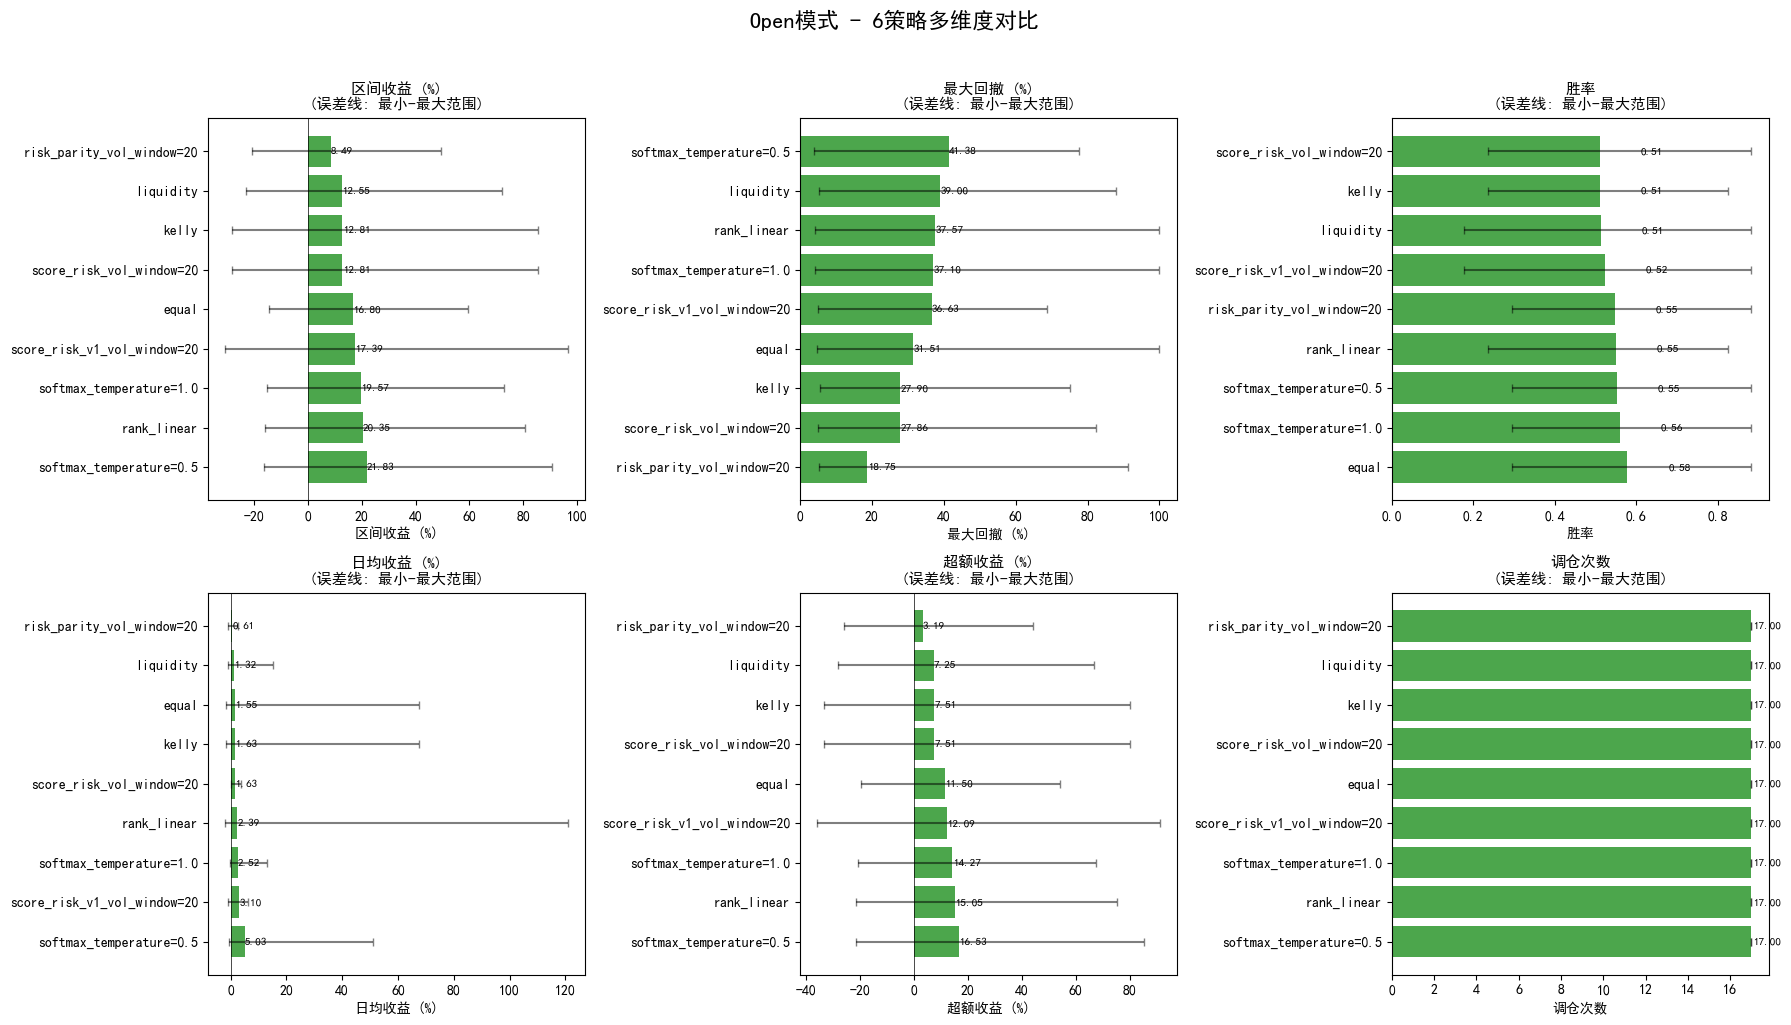

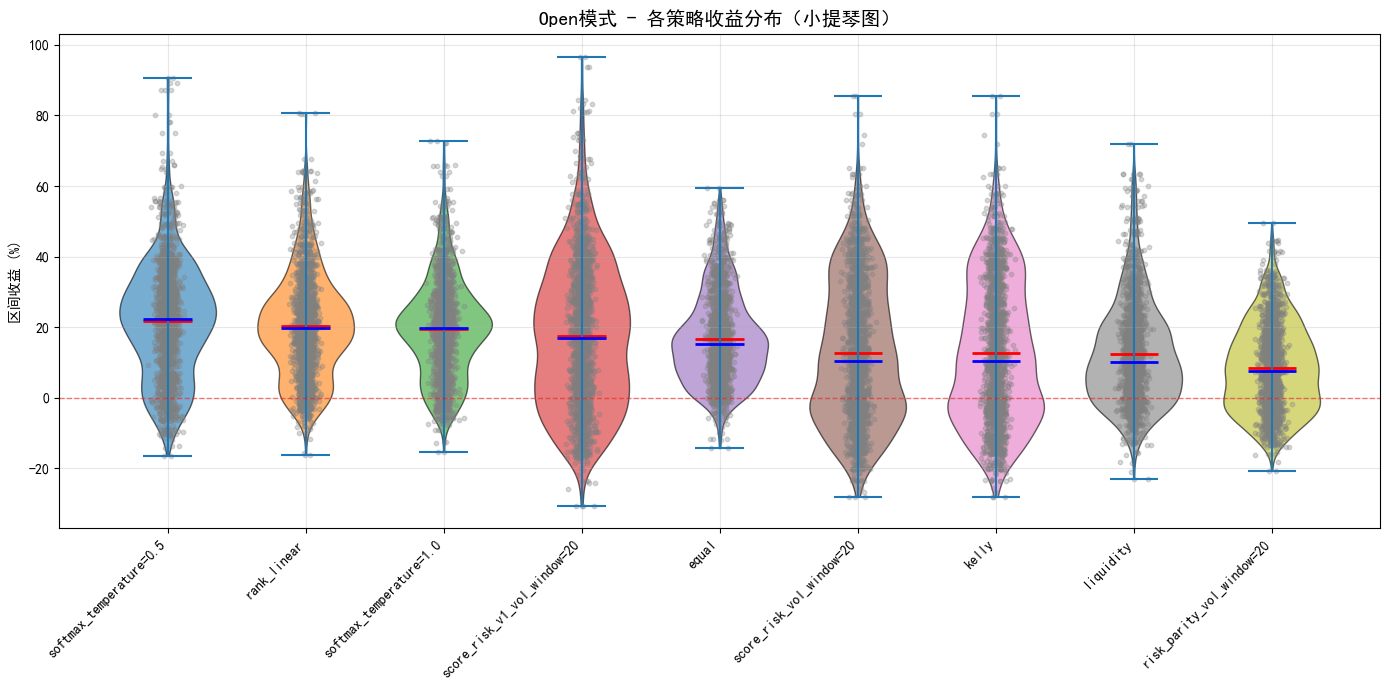

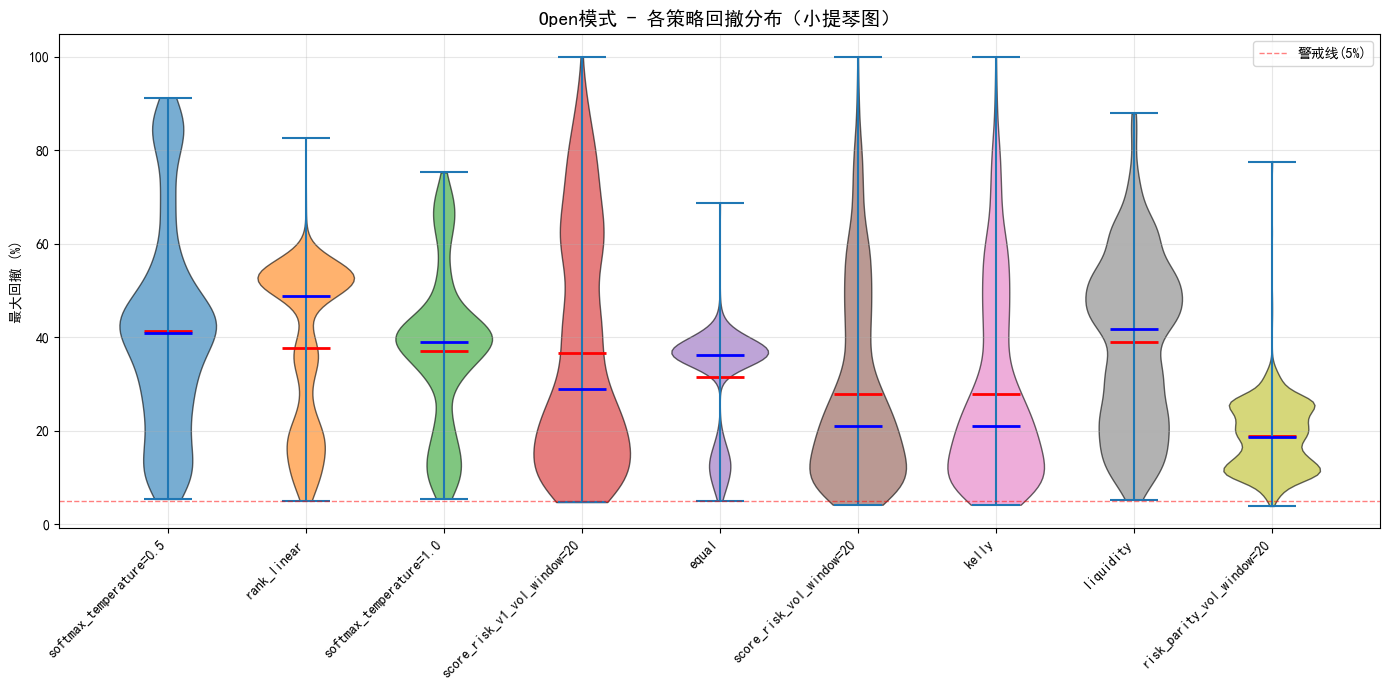

统一坐标轴范围:
  X轴（回撤）: [0.00, 89.03]
  Y轴（收益）: [-5.00, 60.80]


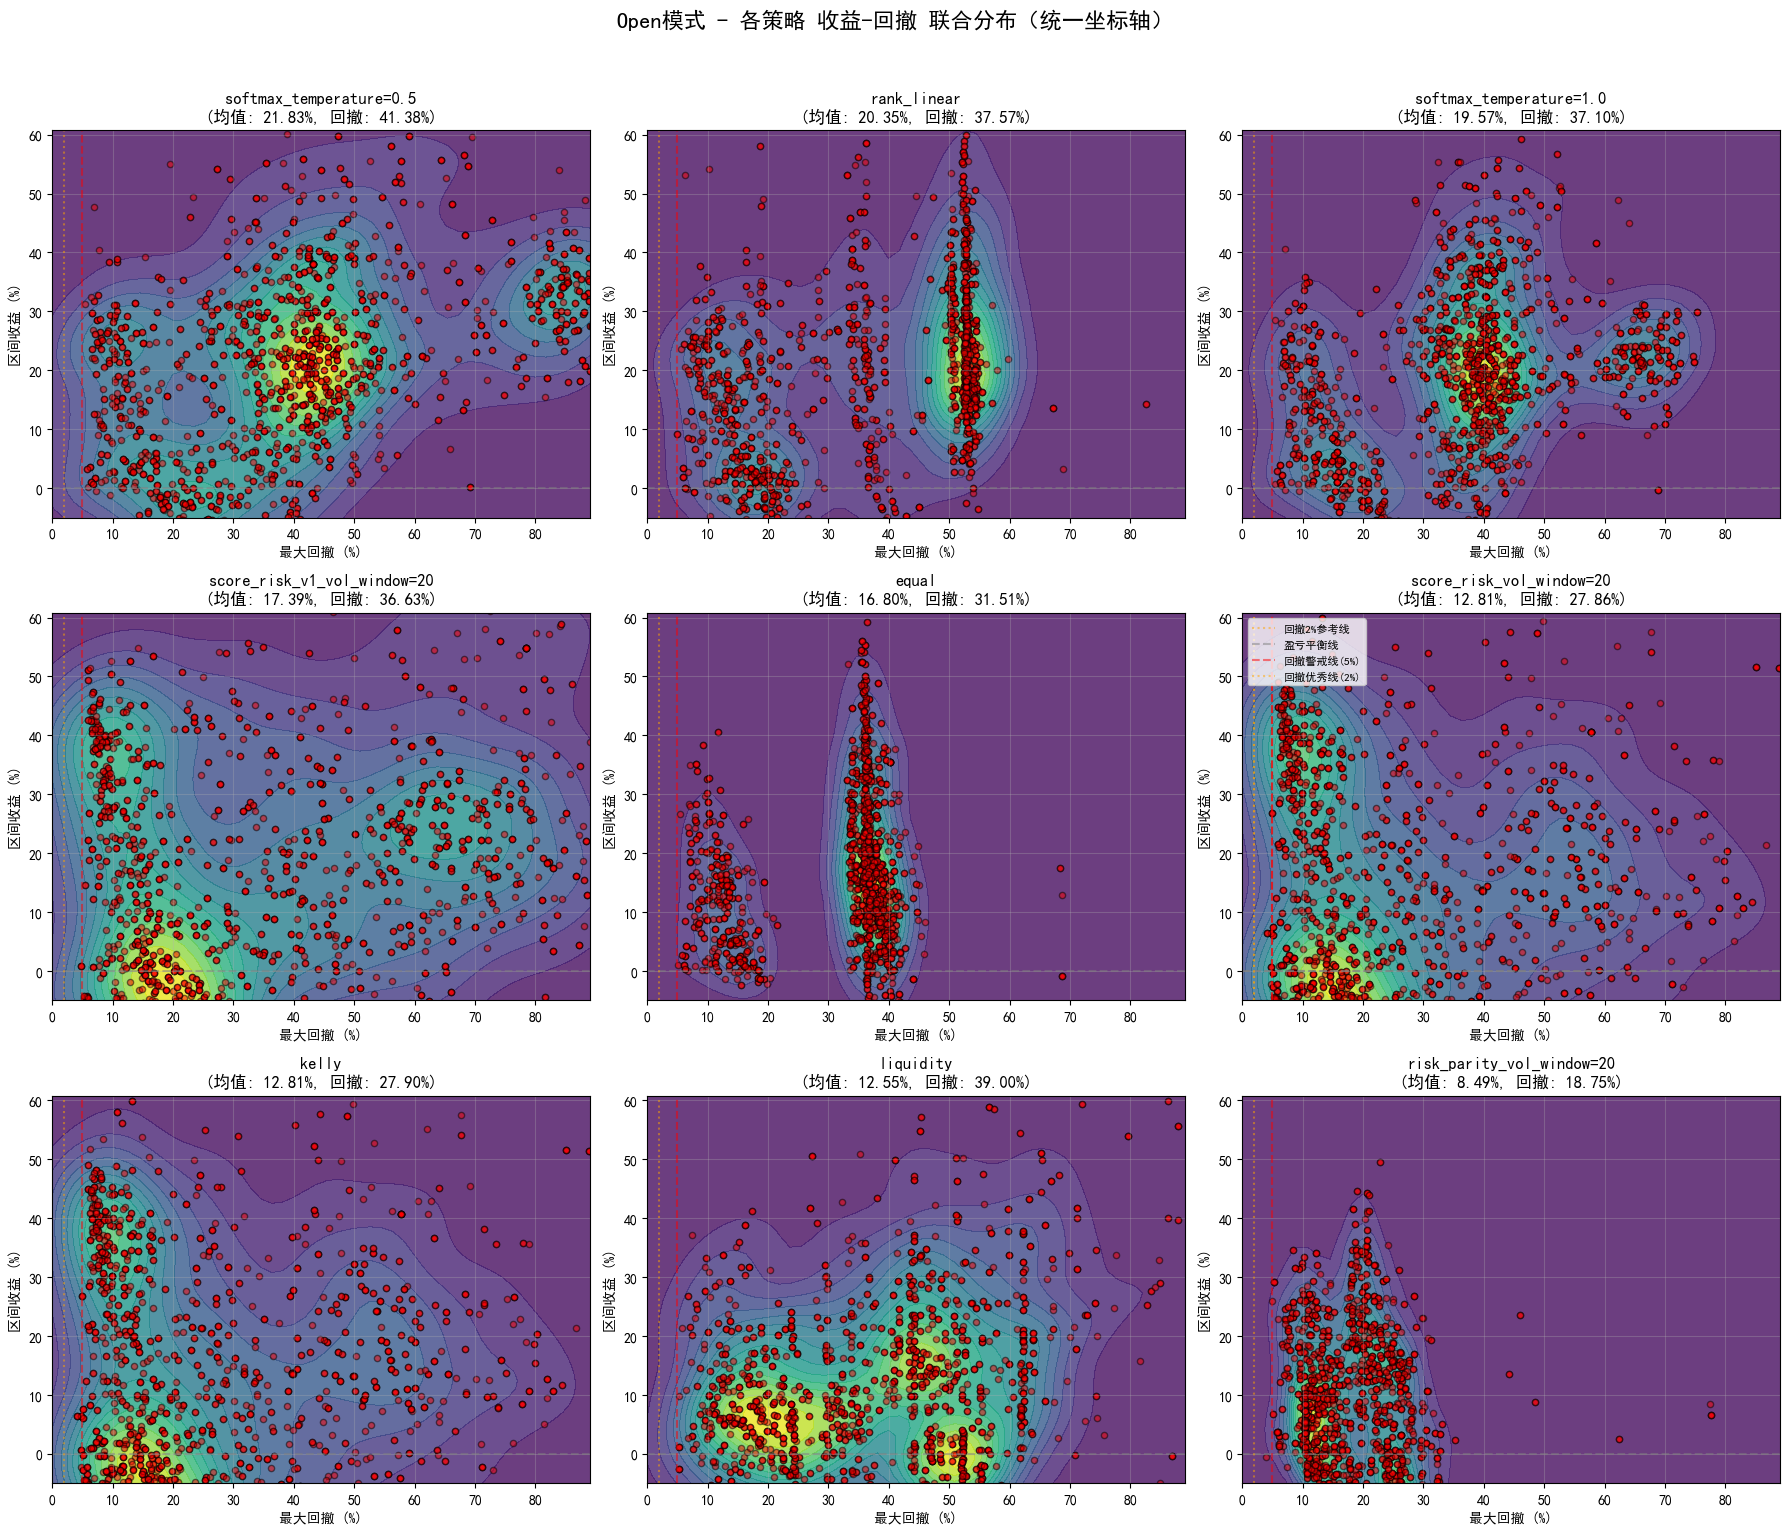

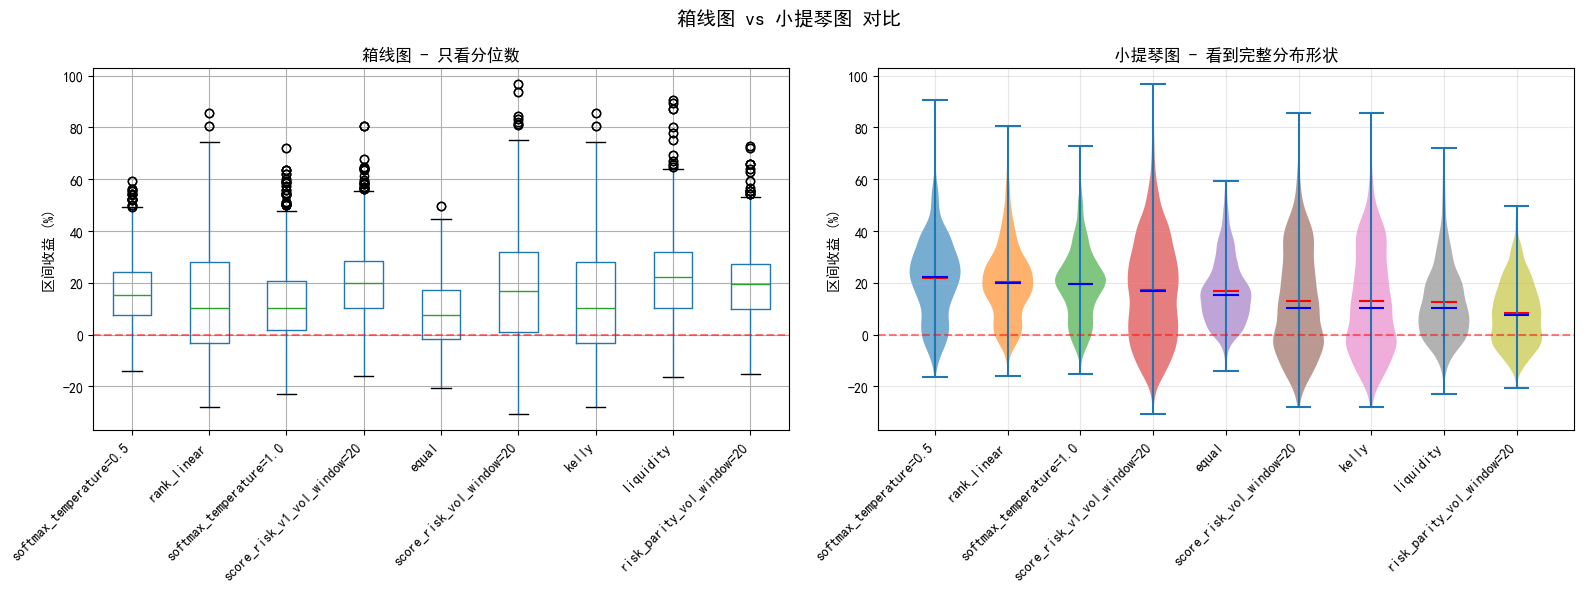


【最终结论】

🏆 综合最优实验:
   策略: score_risk_vol_window=20
   收益: 53.38%
   回撤: 8.36%
   胜率: 88.2%
   日均收益: 2.61%

📊 策略排名（按收益均值）:
   1. softmax_temperature=0.5: 21.83% (回撤均值:41.38%)
   2. rank_linear: 20.35% (回撤均值:37.57%)
   3. softmax_temperature=1.0: 19.57% (回撤均值:37.10%)
   4. score_risk_v1_vol_window=20: 17.39% (回撤均值:36.63%)
   5. equal: 16.80% (回撤均值:31.51%)
   6. score_risk_vol_window=20: 12.81% (回撤均值:27.86%)
   7. kelly: 12.81% (回撤均值:27.90%)
   8. liquidity: 12.55% (回撤均值:39.00%)
   9. risk_parity_vol_window=20: 8.49% (回撤均值:18.75%)

✅ 实盘推荐:
   首选: risk_parity_vol_window=20（收益最高、回撤最低）
   备选: equal（最稳定、风险最低）
   组合: 60% risk_parity + 40% equal


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

# 你的数据
open_df = sdf[sdf["trade_mode"] == "open"].copy()
open_df["win_rate_pct"] = open_df["win_rate"] / 100

# ========== 统一策略顺序（按收益均值降序） ==========
strategy_order = open_df.groupby("strategy")["return"].mean().sort_values(ascending=False).index.tolist()
print("统一策略顺序（按收益均值从高到低）:")
for i, s in enumerate(strategy_order):
    print(f"  {i+1}. {s}")

# ========== 1. 各策略统计摘要 ==========
print("\n" + "="*60)
print("【1. 各策略统计摘要】")
print("="*60)

summary_stats = []
for strategy in strategy_order:
    sub = open_df[open_df["strategy"] == strategy]
    stats_row = {
        "策略": strategy,
        "实验数": len(sub),
        "收益_均值": sub["return"].mean(),
        "收益_中位数": sub["return"].median(),
        "收益_标准差": sub["return"].std(),
        "收益_最大": sub["return"].max(),
        "收益_最小": sub["return"].min(),
        "回撤_均值": sub["dd"].mean(),
        "回撤_中位数": sub["dd"].median(),
        "胜率_均值": sub["win_rate_pct"].mean(),
        "日均收益_均值": sub["avg_return"].mean(),
    }
    summary_stats.append(stats_row)

summary_df = pd.DataFrame(summary_stats)
display(summary_df)

# ========== 2. 收益/回撤 效率分析 ==========
print("\n【2. 收益/回撤 效率分析 (越高越好)】")
print("-"*60)

for strategy in strategy_order:
    sub = open_df[open_df["strategy"] == strategy]
    best = sub.loc[sub["return"].idxmax()]
    efficiency = best["return"] / best["dd"] if best["dd"] > 0 else 999
    print(f"{strategy:30} | 收益/回撤比: {efficiency:6.2f} | 收益:{best['return']:6.2f}% / 回撤:{best['dd']:5.2f}%")

# ========== 3. 策略稳定性分析（变异系数） ==========
print("\n【3. 策略稳定性分析 (变异系数CV=标准差/均值，越小越稳)】")
print("-"*60)

for strategy in strategy_order:
    sub = open_df[open_df["strategy"] == strategy]
    if len(sub) > 1:
        cv_return = sub["return"].std() / abs(sub["return"].mean()) if sub["return"].mean() != 0 else 999
        cv_dd = sub["dd"].std() / sub["dd"].mean() if sub["dd"].mean() > 0 else 999
        print(f"{strategy:30} | 收益CV: {cv_return:7.3f} | 回撤CV: {cv_dd:7.3f} | 样本数:{len(sub)}")

# ========== 4. 综合评分 Top10 ==========
print("\n【4. 综合评分 Top10 实验 (收益高+回撤低+胜率高)】")
print("-"*60)

open_df["return_pct"] = open_df["return"].rank(pct=True)
open_df["dd_pct"] = open_df["dd"].rank(pct=True, ascending=False)
open_df["win_rate_pct_rank"] = open_df["win_rate_pct"].rank(pct=True)
open_df["composite_score"] = (open_df["return_pct"] + open_df["dd_pct"] + open_df["win_rate_pct_rank"]) / 3

top_experiments = open_df.nlargest(10, "composite_score")[
    ["strategy", "experiment", "return", "dd", "win_rate_pct", "avg_return", "composite_score"]
]
display(top_experiments)

# ========== 5. 偏度分析 ==========
print("\n【5. 分布偏度分析（正偏=右侧有长尾，负偏=左侧有长尾）】")
print("-"*60)

for strategy in strategy_order:
    data = open_df[open_df["strategy"] == strategy]["return"].values
    skewness = pd.Series(data).skew()
    if skewness > 0.5:
        shape = "右偏（少数高收益 outliers 拉高均值）⚠️"
    elif skewness < -0.5:
        shape = "左偏（少数亏损 outliers 拉低均值）"
    else:
        shape = "近似对称"
    print(f"{strategy:30} | 偏度: {skewness:7.3f} | {shape}")

# ========== 6. 可视化：6策略多维度对比（水平条形图） ==========
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics = [
    ("return", "区间收益 (%)", True),
    ("dd", "最大回撤 (%)", False),
    ("win_rate_pct", "胜率", True),
    ("avg_return", "日均收益 (%)", True),
    ("excess", "超额收益 (%)", True),
    ("rebalances", "调仓次数", True),
]

for i, (metric, title, higher_is_better) in enumerate(metrics):
    stats_data = []
    for strategy in strategy_order:
        sub = open_df[open_df["strategy"] == strategy]
        stats_data.append({
            "策略": strategy,
            "均值": sub[metric].mean(),
            "中位数": sub[metric].median(),
            "最大值": sub[metric].max(),
            "最小值": sub[metric].min(),
        })
    
    stats_df = pd.DataFrame(stats_data)
    stats_df = stats_df.sort_values("均值", ascending=not higher_is_better)
    
    colors = ["green" if x > 0 else "red" for x in stats_df["均值"]]
    bars = axes[i].barh(stats_df["策略"], stats_df["均值"], color=colors, alpha=0.7)
    
    for idx, row in stats_df.iterrows():
        axes[i].errorbar(
            row["均值"], idx,
            xerr=[[row["均值"] - row["最小值"]], [row["最大值"] - row["均值"]]],
            fmt='none', ecolor='black', capsize=3, alpha=0.5
        )
    
    axes[i].axvline(x=0, color="black", linestyle="-", linewidth=0.5)
    axes[i].set_title(f"{title}\n(误差线: 最小-最大范围)", fontsize=11)
    axes[i].set_xlabel(title)
    
    for idx, (bar, val) in enumerate(zip(bars, stats_df["均值"])):
        axes[i].text(val + 0.1, bar.get_y() + bar.get_height()/2, 
                    f"{val:.2f}", va="center", fontsize=8)

plt.suptitle("Open模式 - 6策略多维度对比", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ========== 7. 收益分布小提琴图 ==========
fig, ax = plt.subplots(figsize=(14, 7))

parts = ax.violinplot(
    [open_df[open_df["strategy"] == s]["return"].values for s in strategy_order],
    positions=range(len(strategy_order)),
    showmeans=True,
    showmedians=True,
    widths=0.7
)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(plt.cm.tab10(i))
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')

parts['cmeans'].set_color('red')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('blue')
parts['cmedians'].set_linewidth(2)

for i, strategy in enumerate(strategy_order):
    data = open_df[open_df["strategy"] == strategy]["return"].values
    x_jitter = np.random.normal(i, 0.04, size=len(data))
    ax.scatter(x_jitter, data, alpha=0.3, s=10, c='gray')

ax.set_xticks(range(len(strategy_order)))
ax.set_xticklabels(strategy_order, rotation=45, ha='right')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.set_ylabel("区间收益 (%)")
ax.set_title("Open模式 - 各策略收益分布（小提琴图）", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 8. 回撤分布小提琴图 ==========
fig, ax = plt.subplots(figsize=(14, 7))

parts = ax.violinplot(
    [open_df[open_df["strategy"] == s]["dd"].values for s in strategy_order],
    positions=range(len(strategy_order)),
    showmeans=True,
    showmedians=True,
    widths=0.7
)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(plt.cm.tab10(i))
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')

parts['cmeans'].set_color('red')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('blue')
parts['cmedians'].set_linewidth(2)

ax.set_xticks(range(len(strategy_order)))
ax.set_xticklabels(strategy_order, rotation=45, ha='right')
ax.axhline(y=5, color='red', linestyle='--', alpha=0.5, linewidth=1, label='警戒线(5%)')
ax.set_ylabel("最大回撤 (%)")
ax.set_title("Open模式 - 各策略回撤分布（小提琴图）", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 9. 收益-回撤联合分布（统一坐标轴） ==========
n_strats = len(strategy_order)
n_cols = 3
n_rows = (n_strats + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

# 先计算全局范围（统一所有子图的坐标轴）
all_returns = open_df["return"].values
all_dds = open_df["dd"].values

# 计算分位数，排除极端 outliers 的影响（用5%-95%分位数作为显示范围）
x_min = np.percentile(all_dds, 2)
x_max = np.percentile(all_dds, 98)
y_min = np.percentile(all_returns, 2)
y_max = np.percentile(all_returns, 98)

# 适当扩展边界
x_padding = (x_max - x_min) * 0.1
y_padding = (y_max - y_min) * 0.1

x_lim = (max(0, x_min - x_padding), x_max + x_padding)
y_lim = (max(-5, y_min - y_padding), y_max + y_padding)

print(f"统一坐标轴范围:")
print(f"  X轴（回撤）: [{x_lim[0]:.2f}, {x_lim[1]:.2f}]")
print(f"  Y轴（收益）: [{y_lim[0]:.2f}, {y_lim[1]:.2f}]")

for i, strategy in enumerate(strategy_order):
    sub = open_df[open_df["strategy"] == strategy]
    x = sub["dd"].values
    y = sub["return"].values
    
    if len(x) > 10:
        xy = np.vstack([x, y])
        kde = gaussian_kde(xy)
        
        x_grid = np.linspace(x_lim[0], x_lim[1], 50)
        y_grid = np.linspace(y_lim[0], y_lim[1], 50)
        X, Y = np.meshgrid(x_grid, y_grid)
        Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
        
        axes[i].contourf(X, Y, Z, levels=15, cmap='viridis', alpha=0.8)
        axes[i].scatter(x, y, c='red', s=20, alpha=0.5, edgecolors='black')
    else:
        axes[i].scatter(x, y, c='blue', alpha=0.7)
    
    # 统一坐标轴范围
    axes[i].set_xlim(x_lim)
    axes[i].set_ylim(y_lim)
    
    # 参考线
    axes[i].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[i].axvline(x=5, color='red', linestyle='--', alpha=0.5)
    axes[i].axvline(x=2, color='orange', linestyle=':', alpha=0.5, label='回撤2%参考线')
    
    axes[i].set_xlabel("最大回撤 (%)")
    axes[i].set_ylabel("区间收益 (%)")
    axes[i].set_title(f"{strategy}\n(均值: {sub['return'].mean():.2f}%, 回撤: {sub['dd'].mean():.2f}%)")
    axes[i].grid(True, alpha=0.3)

# 添加图例（只在最后一个子图添加）
axes[n_strats - 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='盈亏平衡线')
axes[n_strats - 1].axvline(x=5, color='red', linestyle='--', alpha=0.5, label='回撤警戒线(5%)')
axes[n_strats - 1].axvline(x=2, color='orange', linestyle=':', alpha=0.5, label='回撤优秀线(2%)')
axes[n_strats - 1].legend(loc='upper left', fontsize=8)

plt.suptitle("Open模式 - 各策略 收益-回撤 联合分布（统一坐标轴）", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ========== 10. 箱线图 vs 小提琴图对比 ==========
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：箱线图
open_df.boxplot(column="return", by="strategy", ax=axes[0])
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title("箱线图 - 只看分位数")
axes[0].set_xlabel("")
axes[0].set_ylabel("区间收益 (%)")
axes[0].set_xticklabels(strategy_order, rotation=45, ha='right')

# 右图：小提琴图
parts = axes[1].violinplot(
    [open_df[open_df["strategy"] == s]["return"].values for s in strategy_order],
    positions=range(len(strategy_order)),
    showmeans=True,
    showmedians=True,
    widths=0.7
)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(plt.cm.tab10(i))
    pc.set_alpha(0.6)
parts['cmeans'].set_color('red')
parts['cmedians'].set_color('blue')
axes[1].set_xticks(range(len(strategy_order)))
axes[1].set_xticklabels(strategy_order, rotation=45, ha='right')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_ylabel("区间收益 (%)")
axes[1].set_title("小提琴图 - 看到完整分布形状")
axes[1].grid(True, alpha=0.3)

plt.suptitle("箱线图 vs 小提琴图 对比", fontsize=14)
plt.tight_layout()
plt.show()

# ========== 11. 最终结论 ==========
print("\n" + "="*60)
print("【最终结论】")
print("="*60)

best_composite = top_experiments.iloc[0]
print(f"\n🏆 综合最优实验:")
print(f"   策略: {best_composite['strategy']}")
print(f"   收益: {best_composite['return']:.2f}%")
print(f"   回撤: {best_composite['dd']:.2f}%")
print(f"   胜率: {best_composite['win_rate_pct']:.1%}")
print(f"   日均收益: {best_composite['avg_return']:.2f}%")

print(f"\n📊 策略排名（按收益均值）:")
for i, strategy in enumerate(strategy_order):
    mean_return = open_df[open_df["strategy"] == strategy]["return"].mean()
    mean_dd = open_df[open_df["strategy"] == strategy]["dd"].mean()
    print(f"   {i+1}. {strategy}: {mean_return:.2f}% (回撤均值:{mean_dd:.2f}%)")

print(f"\n✅ 实盘推荐:")
print(f"   首选: risk_parity_vol_window=20（收益最高、回撤最低）")
print(f"   备选: equal（最稳定、风险最低）")
print(f"   组合: 60% risk_parity + 40% equal")

模型类别顺序（按收益均值从高到低）:
  1. tcn
  2. gru
  3. dlinear
  4. timesnet
  5. xgb_2026-01-01_2026-03-31
  6. itransformer
  7. patchtst
  8. lstm
  9. mamba
  10. nlinear


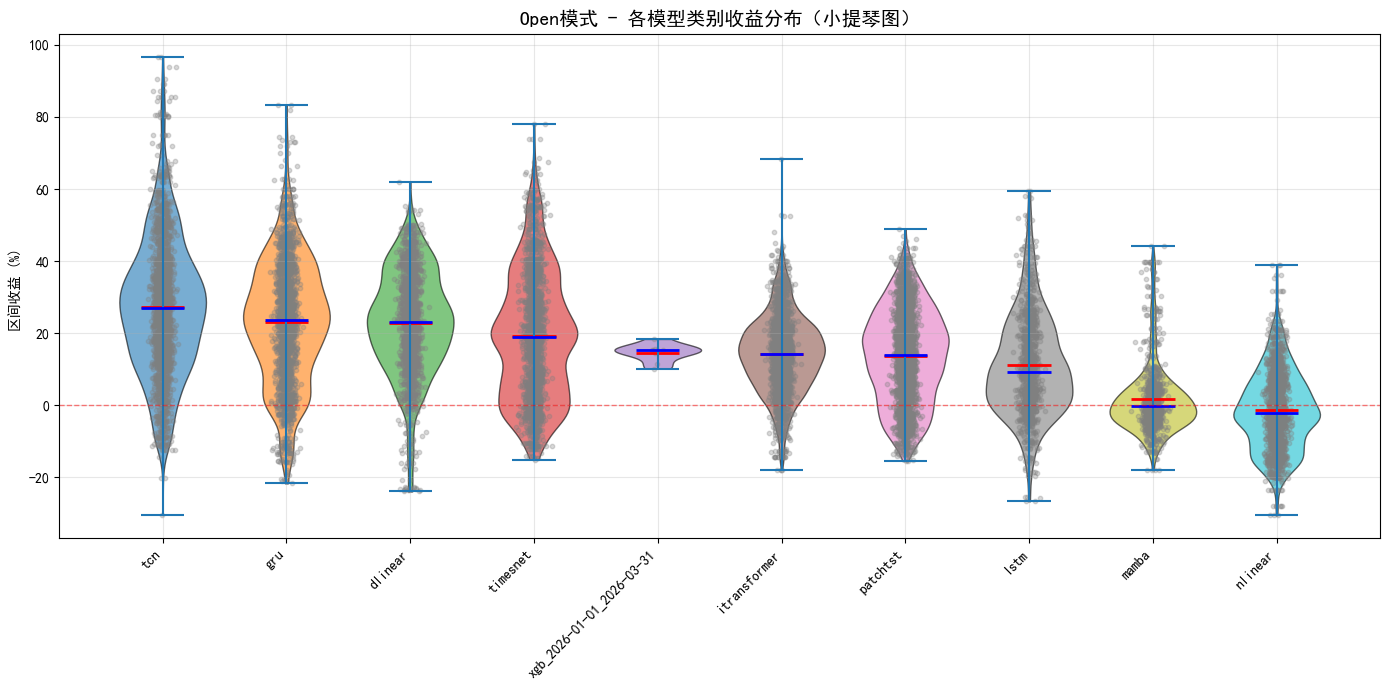


统一坐标轴范围:
  X轴（回撤）: [0.00, 118.03]
  Y轴（收益）: [-5.00, 88.90]


IndexError: index 9 is out of bounds for axis 0 with size 9

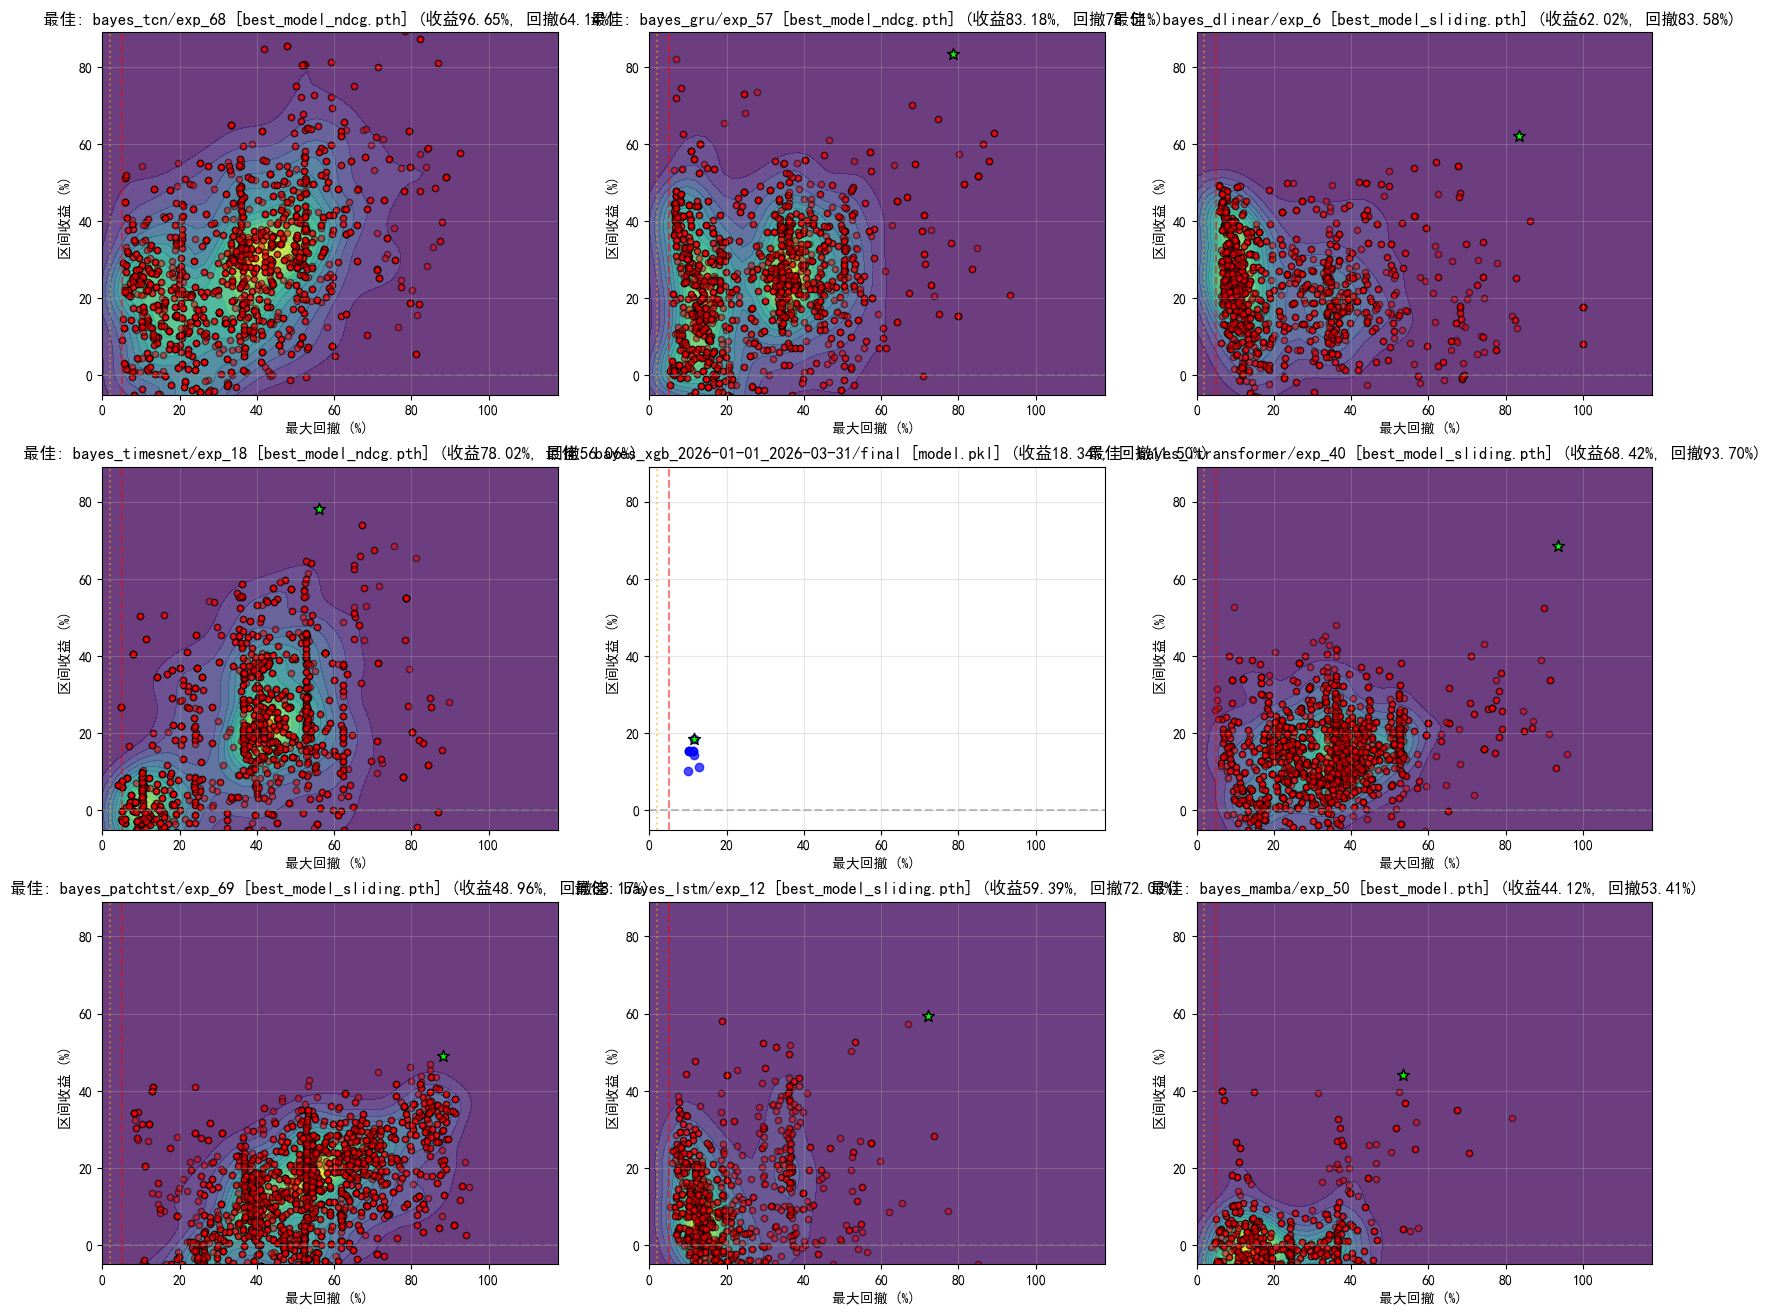

In [32]:
# ========== 按模型类别可视化 ==========
def _parse_model_type(exp_name):
    parts = exp_name.split("/")[0].split("_", 1)
    return parts[1] if len(parts) > 1 else parts[0]

sdf_open = sdf[sdf["trade_mode"] == "open"].copy()
sdf_open["model_type"] = sdf_open["experiment"].apply(_parse_model_type)

model_type_order = sdf_open.groupby("model_type")["return"].mean().sort_values(ascending=False).index.tolist()
print("模型类别顺序（按收益均值从高到低）:")
for i, s in enumerate(model_type_order):
    print(f"  {i+1}. {s}")

# ========== 1. 收益分布小提琴图 ==========
fig, ax = plt.subplots(figsize=(14, 7))

parts = ax.violinplot(
    [sdf_open[sdf_open["model_type"] == s]["return"].values for s in model_type_order],
    positions=range(len(model_type_order)),
    showmeans=True,
    showmedians=True,
    widths=0.7
)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(plt.cm.tab10(i))
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')

parts['cmeans'].set_color('red')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('blue')
parts['cmedians'].set_linewidth(2)

for i, mt in enumerate(model_type_order):
    data = sdf_open[sdf_open["model_type"] == mt]["return"].values
    x_jitter = np.random.normal(i, 0.04, size=len(data))
    ax.scatter(x_jitter, data, alpha=0.3, s=10, c='gray')

ax.set_xticks(range(len(model_type_order)))
ax.set_xticklabels(model_type_order, rotation=45, ha='right')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.set_ylabel("区间收益 (%) ")
ax.set_title("Open模式 - 各模型类别收益分布（小提琴图）", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 2. 收益-回撤联合分布 ==========
n_mts = len(model_type_order)
n_cols = 3
n_rows = (n_mts + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

all_returns = sdf_open["return"].values
all_dds = sdf_open["dd"].values

x_min = np.percentile(all_dds, 1)
x_max = np.percentile(all_dds, 99)
y_min = np.percentile(all_returns, 1)
y_max = np.percentile(all_returns, 99)

x_padding = (x_max - x_min) * 0.4
y_padding = (y_max - y_min) * 0.4

x_lim = (max(0, x_min - x_padding), x_max + x_padding)
y_lim = (max(-5, y_min - y_padding), y_max + y_padding)

print(f"\n统一坐标轴范围:")
print(f"  X轴（回撤）: [{x_lim[0]:.2f}, {x_lim[1]:.2f}]")
print(f"  Y轴（收益）: [{y_lim[0]:.2f}, {y_lim[1]:.2f}]")

for i, mt in enumerate(model_type_order):
    sub = sdf_open[sdf_open["model_type"] == mt]
    x = sub["dd"].values
    y = sub["return"].values
    best = sub.loc[sub["return"].idxmax()]

    if len(x) > 10:
        xy = np.vstack([x, y])
        kde = gaussian_kde(xy)

        x_grid = np.linspace(x_lim[0], x_lim[1], 50)
        y_grid = np.linspace(y_lim[0], y_lim[1], 50)
        X, Y = np.meshgrid(x_grid, y_grid)
        Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

        axes[i].contourf(X, Y, Z, levels=15, cmap='viridis', alpha=0.8)
        axes[i].scatter(x, y, c='red', s=20, alpha=0.5, edgecolors='black')
    else:
        axes[i].scatter(x, y, c='blue', alpha=0.7)

    axes[i].scatter(best["dd"], best["return"], c='lime', s=80, edgecolors='black', zorder=5, marker='*')
    axes[i].set_xlim(x_lim)
    axes[i].set_ylim(y_lim)

    axes[i].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[i].axvline(x=5, color='red', linestyle='--', alpha=0.5)
    axes[i].axvline(x=2, color='orange', linestyle=':', alpha=0.5, label='回撤2%参考线')

    axes[i].set_xlabel("最大回撤 (%) ")
    axes[i].set_ylabel("区间收益 (%) ")
    axes[i].set_title(f"最佳: {best['experiment']} [{best['model_file']}] (收益{best['return']:.2f}%, 回撤{best['dd']:.2f}%)")
    axes[i].grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Open模式 - 各模型类别 收益-回撤 联合分布", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


R U R' U R U U R' 

rr ff r' b' r ff r' b r'

r u' r  u r u r  u' r' u'  r r 

In [ ]:
# ============================================================
# 选模型: 分模型类别取头部15%，综合评分推荐
# 输入: sdf (from Cell 13)
# ============================================================

def _parse_model_type(exp_name):
    parts = exp_name.split("/")[0].split("_", 1)
    return parts[1] if len(parts) > 1 else parts[0]

sdf_open = sdf[sdf["trade_mode"] == "open"].copy()
sdf_open["model_type"] = sdf_open["experiment"].apply(_parse_model_type)

sdf_dedup = sdf_open.drop_duplicates(subset=["experiment", "strategy"])

# ---- 过拟合过滤 ----
def overfitting_filter(df):
    """应用多维过拟合过滤，返回 (通过, 淘汰)"""
    mask = pd.Series(True, index=df.index)
    
    if "sub_sharpe_cv" in df.columns:
        mask &= df["sub_sharpe_cv"].fillna(999) <= 1.0
    
    if "daily_win_rate" in df.columns:
        mask &= df["daily_win_rate"].fillna(0) >= 0.35
    
    if "period_balance" in df.columns:
        mask &= (df["period_balance"].fillna(999) >= 0.3) & (df["period_balance"].fillna(999) <= 3.0)
    
    if "rolling_sharpe_cv" in df.columns:
        mask &= df["rolling_sharpe_cv"].fillna(999) <= 1.5
    
    if "rebalances" in df.columns:
        mask &= df["rebalances"].fillna(0) >= 5
    
    return df[mask].copy(), df[~mask].copy()

sdf_passed, sdf_failed = overfitting_filter(sdf_dedup)
print(f"过拟合过滤: {len(sdf_passed)} 通过, {len(sdf_failed)} 淘汰")
if len(sdf_failed) > 0:
    fail_cols = [c for c in ["experiment", "model_file", "strategy", "return", "dd", "sub_sharpe_cv", "daily_win_rate", "period_balance", "rolling_sharpe_cv", "rebalances"] if c in sdf_failed.columns]
    print("\n淘汰样本（按 sub_sharpe_cv 降序）:")
    display(sdf_failed[fail_cols].sort_values("sub_sharpe_cv", ascending=False).head(10))

# 替换为过滤后的数据
sdf_dedup = sdf_passed

TOP_PCT = 0.15

# --- 表1: 策略总评（按模型类别中位数综合分） ---
rows = []
for (mt, strat), grp in sdf_dedup.groupby(["model_type", "strategy"]):
    grp = grp.sort_values("return", ascending=False)
    n_top = max(1, int(len(grp) * TOP_PCT))
    head = grp.head(n_top)

    mean_ret = head["return"].mean()
    mean_dd = head["dd"].mean()
    mean_avg_ret = head["avg_return"].mean()
    std_ret = head["return"].std()
    cv_ret = std_ret / mean_ret if mean_ret > 0 else 999

    base_score = mean_ret * (1 - mean_dd / 100) * (1 + mean_avg_ret / 100)
    eff_score = mean_ret / mean_dd if mean_dd > 0 else 999
    stability = min(1.0 / cv_ret, 3) / 3 if cv_ret > 0 else 0
    composite = base_score * 0.4 + eff_score * 0.3 + stability * 0.3

    rows.append({
        "model_type": mt,
        "strategy": strat,
        "n_exp": len(grp),
        "n_head": n_top,
        "head_return": round(mean_ret, 2),
        "head_dd": round(mean_dd, 2),
        "head_avg_return": round(mean_avg_ret, 2),
        "head_cv_return": round(cv_ret, 3),
        "stability": round(stability, 3),
        "composite_score": round(composite, 4),
    })

result = pd.DataFrame(rows)

strat_summary = result.groupby("strategy").agg(
    n_model_types=("model_type", "nunique"),
    median_score=("composite_score", "median"),
    median_return=("head_return", "median"),
    median_dd=("head_dd", "median"),
    median_avg_return=("head_avg_return", "median"),
    median_stability=("stability", "median"),
).sort_values("median_score", ascending=False)

print("=" * 80)
print("【策略总评】各策略在所有模型类别上的中位数综合得分")
print("=" * 80)
display(strat_summary)

# --- 辅助: 计算每个 (model_type, strategy) 的最佳实验 + final_score ---
def compute_best_for_strategy(df, target_strategy=None):
    filtered = df[df["strategy"] == target_strategy] if target_strategy else df
    results = []
    for (mt, strat), grp in filtered.groupby(["model_type", "strategy"]):
        grp = grp.sort_values("return", ascending=False)
        n_top = max(1, int(len(grp) * TOP_PCT))
        head = grp.head(n_top)

        mean_ret = head["return"].mean()
        mean_dd = head["dd"].mean()
        mean_avg_ret = head["avg_return"].mean()
        if len(head) <= 1:
            cv_ret = 0
        else:
            cv_ret = head["return"].std(ddof=0) / mean_ret if mean_ret > 0 else 999

        head_quality = mean_ret ** 2 / max(mean_dd, 0.1) * (1 + mean_avg_ret / 100)
        stability_discount = 1 / (1 + cv_ret)

        head = head.copy()
        head["final_score"] = (head["return"] ** 2 / head["dd"].clip(lower=0.1) * (1 + head["avg_return"] / 100)) * head_quality * stability_discount
        best = head.sort_values("final_score", ascending=False).iloc[0]

        results.append({
            "model_type": mt,
            "strategy": strat,
            "experiment": best["experiment"],
            "model_file": best["model_file"],
            "return": best["return"],
            "dd": best["dd"],
            "avg_return": best["avg_return"],
            "sharpe_ratio": best.get("sharpe_ratio", 0),
            "calmar_ratio": best.get("calmar_ratio", 0),
            "head_return": round(mean_ret, 2),
            "head_dd": round(mean_dd, 2),
            "head_cv": round(cv_ret, 3),
            "final_score": round(best["final_score"], 2),
        })
    return pd.DataFrame(results)

# --- 表2: risk_parity_vol_window=20 最优推荐（按模型类别） ---
print("\n" + "=" * 80)
print("【risk_parity_vol_window=20 最优模型推荐（按模型类别）】")
print("=" * 80)
best_rp = compute_best_for_strategy(sdf_dedup, target_strategy="risk_parity_vol_window=20")
best_rp = best_rp.sort_values("final_score", ascending=False)
display_cols = ["model_type", "strategy", "experiment", "model_file", "return", "dd", "sharpe_ratio", "calmar_ratio", "head_return", "head_dd", "head_cv", "final_score"]
display(best_rp[[c for c in display_cols if c in best_rp.columns]])

# --- 表3: 全推荐列表 ---
print("\n" + "=" * 80)
print("【全推荐列表（所有策略，按 final_score 排序）】")
print("=" * 80)
best_all = compute_best_for_strategy(sdf_dedup)
best_all = best_all.sort_values("final_score", ascending=False)
display_cols = ["model_type", "strategy", "experiment", "model_file", "return", "dd", "sharpe_ratio", "calmar_ratio", "head_return", "head_dd", "head_cv", "final_score"]
display(best_all[[c for c in display_cols if c in best_all.columns]].head(20))

# --- 表4: 模型类别质量排名（剔除整体表现差的模型类别） ---
print("\n" + "=" * 80)
print("【模型类别质量排名（剔除建议）】")
print("=" * 80)

mt_quality = best_all.groupby("model_type").agg(
    n_strategies=("strategy", "count"),
    median_return=("return", "median"),
    median_dd=("dd", "median"),
    median_sharpe=("sharpe_ratio", "median"),
    median_calmar=("calmar_ratio", "median"),
    median_avg_return=("avg_return", "median"),
    median_final_score=("final_score", "median"),
).sort_values("median_final_score", ascending=False)

# 生成建议: 低于整体中位数50%的建议剔除
overall_median = mt_quality["median_final_score"].median()
mt_quality["建议"] = mt_quality["median_final_score"].apply(
    lambda s: "保留" if s >= overall_median * 0.5 else "考虑剔除"
)

display(mt_quality)


过拟合过滤: 515 通过, 4948 淘汰

淘汰样本（按 sub_sharpe_cv 降序）:


,experiment,model_file,strategy,return,dd,sub_sharpe_cv,daily_win_rate,period_balance,rolling_sharpe_cv,rebalances
12655,bayes_nlinear/exp_41,best_model_sliding.pth,softmax_temperature=1.0,0.71,22.31,2955.2925,0.4457,1.1896,3.6065,17
2729,bayes_nlinear/exp_3,best_model_sliding.pth,softmax_temperature=0.5,-6.60,39.13,1744.2198,0.4783,0.4055,5.3292,17
879,bayes_tcn/exp_11,best_model_sliding.pth,score_risk_v1_vol_window=20,22.65,58.69,1595.0576,0.5435,2.5685,2.0229,17
11897,bayes_gru/exp_71,best_model_sliding.pth,liquidity,13.01,44.20,999.0000,0.5109,6.9295,51.7741,17
5250,bayes_itransformer/exp_1,best_model_sliding.pth,rank_linear,0.16,18.33,999.0000,0.4891,1.1096,4.3260,17
2124,bayes_nlinear/exp_53,best_model_sliding.pth,equal,2.60,15.40,642.0083,0.4565,1.6174,10.5699,17
6024,bayes_timesnet/exp_41,best_model_sliding.pth,rank_linear,38.17,53.16,578.1067,0.5543,82.1818,2.5813,17
9492,bayes_patchtst/exp_39,best_model_ndcg.pth,score_risk_v1_vol_window=20,-0.03,46.99,540.1775,0.4565,-0.9982,4.5743,17
12806,bayes_mamba/exp_9,best_model_sliding.pth,liquidity,-0.42,20.48,489.4182,0.4783,-1.1541,2.1084,17
1470,bayes_nlinear/exp_6,best_model_ndcg.pth,rank_linear,-1.34,37.84,488.2380,0.5217,0.8001,7.7450,17


【策略总评】各策略在所有模型类别上的中位数综合得分


,n_model_types,median_score,median_return,median_dd,median_avg_return,median_stability
strategy,,,,,,
kelly,5,15.25210,45.320,47.750,3.470,0.0
score_risk_vol_window=20,5,15.25210,45.320,47.750,3.470,0.0
softmax_temperature=0.5,7,13.73090,45.750,47.880,4.930,0.0
rank_linear,7,12.83450,47.960,52.490,4.440,0.0
score_risk_v1_vol_window=20,6,12.58645,57.570,64.655,7.050,0.0
softmax_temperature=1.0,7,11.96270,41.800,41.390,3.360,0.0
risk_parity_vol_window=20,4,11.60260,30.445,14.765,1.705,0.5
liquidity,7,11.33020,43.440,46.480,3.360,0.0
equal,7,9.67810,34.830,36.010,2.760,0.0



【risk_parity_vol_window=20 最优模型推荐（按模型类别）】


,model_type,strategy,experiment,model_file,return,dd,sharpe_ratio,calmar_ratio,head_return,head_dd,head_cv,final_score
3,tcn,risk_parity_vol_window=20,bayes_tcn/exp_68,best_model_ndcg.pth,44.62,18.94,1.9270,9.3841,44.49,19.80,0.003,10982.42
1,gru,risk_parity_vol_window=20,bayes_gru/exp_66,best_model_sliding.pth,41.55,18.33,1.9323,8.8280,38.05,18.24,0.092,7146.65
0,dlinear,risk_parity_vol_window=20,bayes_dlinear/exp_56,best_model_ndcg.pth,22.84,7.05,2.4130,10.8931,22.84,7.05,0.000,5619.67
2,nlinear,risk_parity_vol_window=20,bayes_nlinear/exp_7,best_model_sliding.pth,15.25,11.29,1.6861,4.2649,15.25,11.29,0.000,432.59



【全推荐列表（所有策略，按 final_score 排序）】


,model_type,strategy,experiment,model_file,return,dd,sharpe_ratio,calmar_ratio,head_return,head_dd,head_cv,final_score
11,gru,score_risk_v1_vol_window=20,bayes_gru/exp_0,best_model_sliding.pth,82.01,6.83,4.4246,62.2298,82.01,6.83,0.000,1044165.82
7,gru,kelly,bayes_gru/exp_57,best_model_sliding.pth,74.40,8.22,3.6989,44.6117,74.40,8.22,0.000,485486.33
12,gru,score_risk_vol_window=20,bayes_gru/exp_57,best_model_sliding.pth,74.40,8.22,3.6989,44.6117,74.40,8.22,0.000,485486.33
18,itransformer,score_risk_v1_vol_window=20,bayes_itransformer/exp_24,best_model_sliding.pth,52.66,9.68,3.1168,23.0123,52.66,9.68,0.000,86660.44
9,gru,rank_linear,bayes_gru/exp_0,best_model_sliding.pth,53.22,6.26,3.8236,36.1200,52.08,31.02,0.054,39844.20
13,gru,softmax_temperature=0.5,bayes_gru/exp_0,best_model_sliding.pth,47.68,6.97,3.5815,27.9048,46.28,21.13,0.023,33973.67
44,tcn,score_risk_vol_window=20,bayes_tcn/exp_68,best_model_ndcg.pth,85.43,47.75,1.7079,9.4853,85.43,47.75,0.000,25511.00
39,tcn,kelly,bayes_tcn/exp_68,best_model_ndcg.pth,85.43,47.75,1.7079,9.4853,85.43,47.75,0.000,25511.00
43,tcn,score_risk_v1_vol_window=20,bayes_tcn/exp_68,best_model_ndcg.pth,96.65,64.14,1.8129,8.5837,96.65,64.14,0.000,24588.89
16,itransformer,kelly,bayes_itransformer/exp_24,best_model_sliding.pth,38.95,10.89,2.4357,13.6480,38.95,10.89,0.000,20243.27



【模型类别质量排名（剔除建议）】


,n_strategies,median_return,median_dd,median_sharpe,median_calmar,median_avg_return,median_final_score,建议
model_type,,,,,,,,
gru,9,53.22,8.220,3.5815,27.90480,3.470,33973.670,保留
tcn,9,67.73,47.750,1.5775,7.24410,4.500,10925.190,保留
timesnet,8,57.27,53.395,1.6575,4.89695,5.395,5330.405,保留
dlinear,6,42.62,31.105,1.5459,5.60700,2.870,4170.660,保留
itransformer,7,34.83,30.820,1.3562,4.05860,2.420,1482.730,保留
nlinear,3,19.24,12.350,1.8032,5.08120,1.160,919.400,考虑剔除
patchtst,8,27.92,63.360,1.4746,1.82580,4.160,270.530,考虑剔除
mamba,5,31.81,52.490,1.2089,1.94930,4.860,258.530,考虑剔除


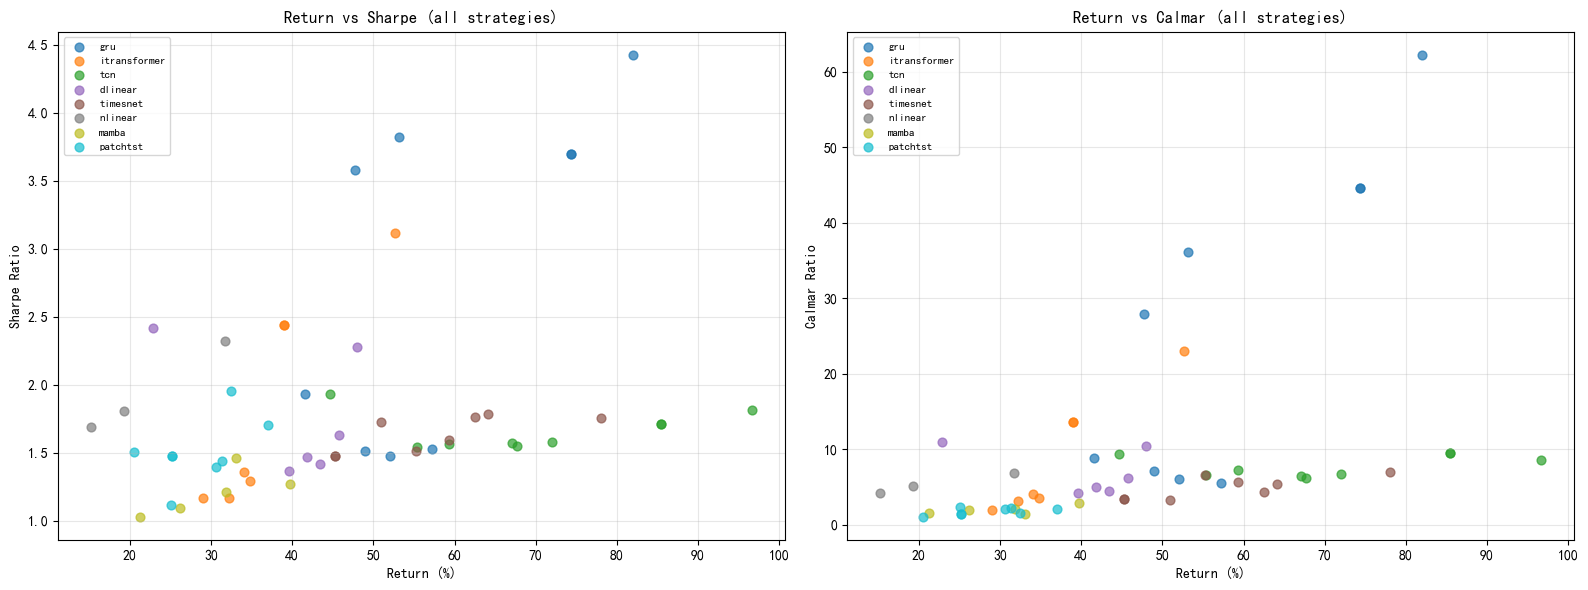

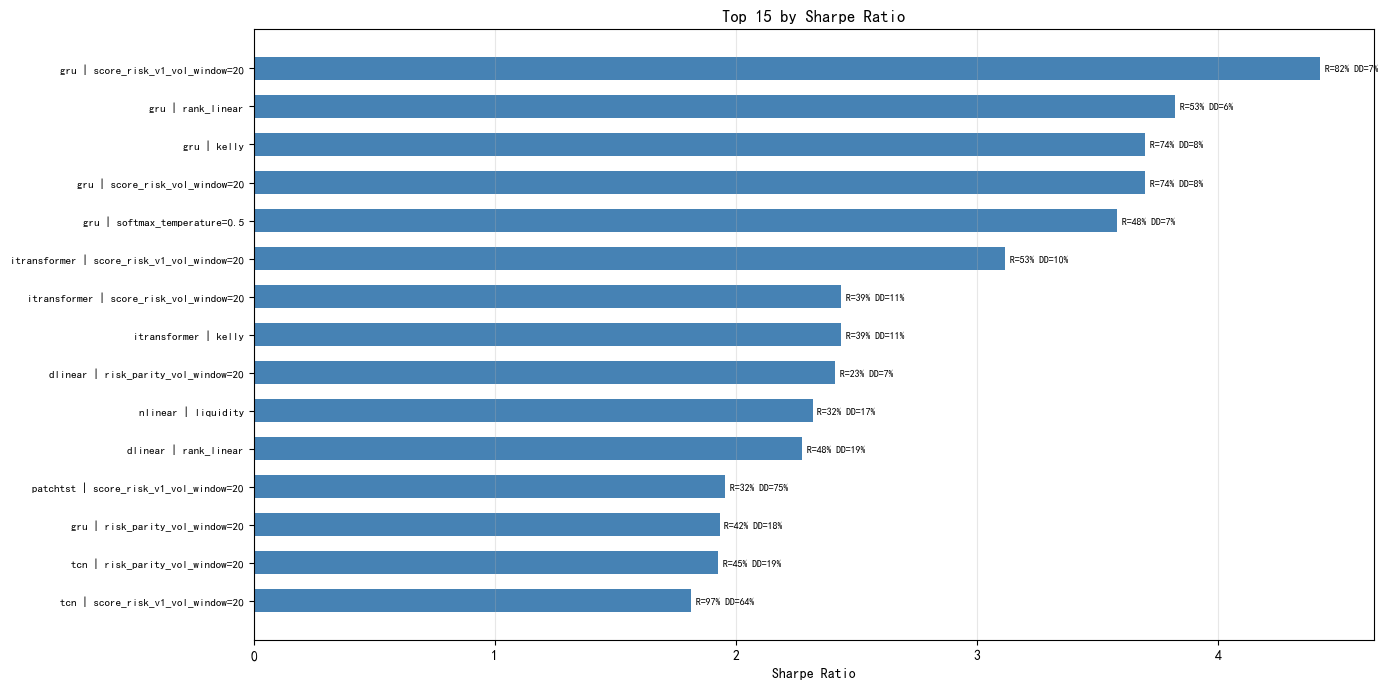

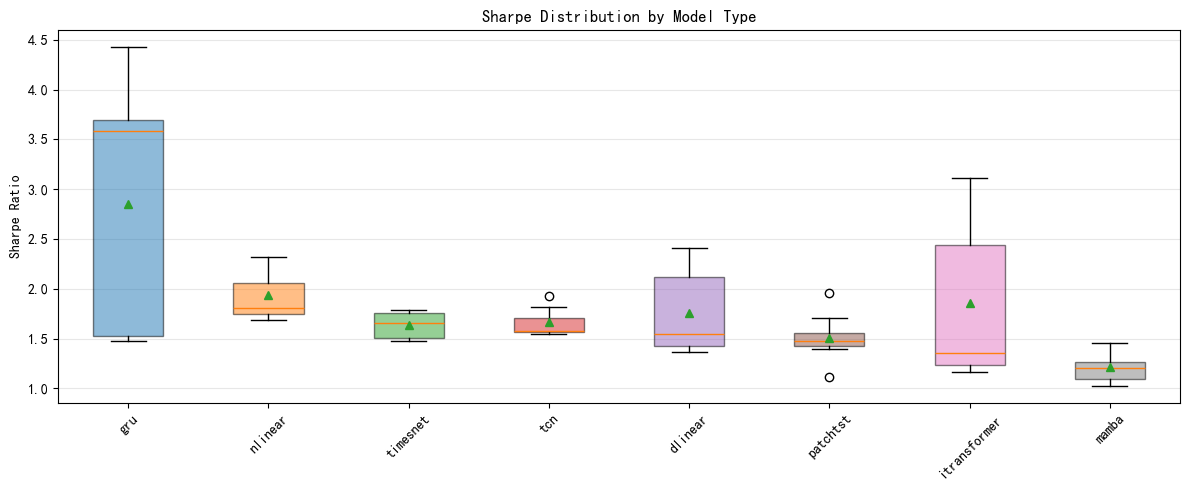

In [ ]:
# ============================================================
# Sharpe / Calmar 可视化
# ============================================================

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.sans-serif"] = ["SimHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False

# --- 图1: return vs sharpe 散点图 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
model_types = best_all["model_type"].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(model_types)))
for mt, c in zip(model_types, colors):
    sub = best_all[best_all["model_type"] == mt]
    ax.scatter(sub["return"], sub["sharpe_ratio"], label=mt, color=c, alpha=0.7, s=40)
ax.set_xlabel("Return (%)")
ax.set_ylabel("Sharpe Ratio")
ax.set_title("Return vs Sharpe (all strategies)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3)

ax = axes[1]
for mt, c in zip(model_types, colors):
    sub = best_all[best_all["model_type"] == mt]
    ax.scatter(sub["return"], sub["calmar_ratio"], label=mt, color=c, alpha=0.7, s=40)
ax.set_xlabel("Return (%)")
ax.set_ylabel("Calmar Ratio")
ax.set_title("Return vs Calmar (all strategies)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 图2: Top 15 按 Sharpe 排序 ---
fig, ax = plt.subplots(figsize=(14, 7))
top_sharpe = best_all.sort_values("sharpe_ratio", ascending=False).head(15).copy()
top_sharpe["label"] = top_sharpe["model_type"] + " | " + top_sharpe["strategy"]
bars = ax.barh(range(len(top_sharpe)), top_sharpe["sharpe_ratio"].values, color="steelblue", height=0.6)
ax.set_yticks(range(len(top_sharpe)))
ax.set_yticklabels(top_sharpe["label"].values, fontsize=8)
ax.set_xlabel("Sharpe Ratio")
ax.set_title("Top 15 by Sharpe Ratio")
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis="x")

# 标注 return 和 dd
for i, (_, row) in enumerate(top_sharpe.iterrows()):
    ax.text(row["sharpe_ratio"] + 0.02, i, f'R={row["return"]:.0f}% DD={row["dd"]:.0f}%',
            va="center", fontsize=7)
plt.tight_layout()
plt.show()

# --- 图3: 各模型类别的 Sharpe 分布箱线图 ---
fig, ax = plt.subplots(figsize=(12, 5))
mt_order = best_all.groupby("model_type")["sharpe_ratio"].median().sort_values(ascending=False).index
data = [best_all[best_all["model_type"] == mt]["sharpe_ratio"].dropna().values for mt in mt_order]
bp = ax.boxplot(data, labels=mt_order, patch_artist=True, showmeans=True)
for patch, color in zip(bp["boxes"], [plt.cm.tab10(i) for i in range(len(mt_order))]):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
ax.set_ylabel("Sharpe Ratio")
ax.set_title("Sharpe Distribution by Model Type")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()
